In [83]:
import pandas as pd
import os

# Configuration du chemin local (Dossier visible dans ton explorateur VS Code)
DATA_DIR = "Data_SNDT"
CSV_PATH = os.path.join(DATA_DIR, "pipe_detection_label.csv")

# Chargement du CSV
df = pd.read_csv(CSV_PATH, sep=';')

# --- L'ANALYSE INDISPENSABLE ---
print("--- APERÇU DES 5 PREMIÈRES LIGNES (.head) ---")
display(df.head())

print("\n--- STATISTIQUES DES DONNÉES (.describe) ---")
display(df.describe())

print("\n--- RÉPARTITION DES CLASSES (Tâche 1) ---")
print(df['label'].value_counts())

--- APERÇU DES 5 PREMIÈRES LIGNES (.head) ---


,field_file,label,width_m,coverage_type,shape,noisy,noise_type,pipe_type
0,sample_00000_perfect_straight_clean_field.npz,1,62.40,perfect,straight,False,NaN,single
1,sample_00001_perfect_straight_clean_field.npz,1,41.08,perfect,straight,False,NaN,single
2,sample_00002_perfect_straight_clean_field.npz,1,42.34,perfect,straight,False,NaN,single
3,sample_00003_perfect_straight_clean_field.npz,1,4.96,perfect,straight,False,NaN,single
4,sample_00004_perfect_straight_clean_field.npz,1,35.96,perfect,straight,False,NaN,single



--- STATISTIQUES DES DONNÉES (.describe) ---


,label,width_m
count,2935.000000,1751.000000
mean,0.596593,36.934272
std,0.490665,33.576720
min,0.000000,2.010000
25%,0.000000,11.125000
50%,1.000000,25.640000
75%,1.000000,54.750000
max,1.000000,154.840000



--- RÉPARTITION DES CLASSES (Tâche 1) ---
label
1    1751
0    1184
Name: count, dtype: int64


In [84]:
import pandas as pd
import os
import numpy as np

# Chemins
DATA_DIR = "Data_SNDT"
CSV_PATH = os.path.join(DATA_DIR, "pipe_detection_label.csv")

# 1. Chargement
df = pd.read_csv(CSV_PATH, sep=';')

# 2. Analyse de base (Les chiffres que tu voulais)
total_samples = len(df)
presence = df[df['label'] == 1]
absence = df[df['label'] == 0]

print(f"--- ANALYSE DU DATASET ---")
print(f"Nombre total d'échantillons : {total_samples}")
print(f"Présence (1) : {len(presence)} ({len(presence)/total_samples:.1%})")
print(f"Absence (0)  : {len(absence)} ({len(absence)/total_samples:.1%})")

# 3. Vérification de l'existence des fichiers (Crucial !)
df['file_exists'] = df['field_file'].apply(lambda x: os.path.exists(os.path.join(DATA_DIR, x)))
missing_files = df[df['file_exists'] == False]

if len(missing_files) > 0:
    print(f"ATTENTION : {len(missing_files)} fichiers sont introuvables dans {DATA_DIR} !")
else:
    print("Tous les fichiers listés dans le CSV sont présents dans le dossier.")

--- ANALYSE DU DATASET ---
Nombre total d'échantillons : 2935
Présence (1) : 1751 (59.7%)
Absence (0)  : 1184 (40.3%)
Tous les fichiers listés dans le CSV sont présents dans le dossier.


In [4]:
# Charger un échantillon de test
test_file = df.iloc[0]['field_file']
sample_data = np.load(os.path.join(DATA_DIR, test_file))['data']

print(f"\n--- STRUCTURE D'UN FICHIER ---")
print(f"Dimensions (H, W, Canaux) : {sample_data.shape}")
print(f"Valeur Max (nT) : {np.nanmax(sample_data):.2f}")
print(f"Valeur Min (nT) : {np.nanmin(sample_data):.2f}")
print(f"Nombre de NaN : {np.isnan(sample_data).sum()}")


--- STRUCTURE D'UN FICHIER ---
Dimensions (H, W, Canaux) : (853, 901, 4)
Valeur Max (nT) : 29.48
Valeur Min (nT) : 0.00
Nombre de NaN : 1773944


In [1]:
import pandas as pd
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import cv2

# ============================================================
# CONFIGURATION
# ============================================================
DATA_DIR   = "Data_SNDT"
CSV_PATH   = os.path.join(DATA_DIR, "pipe_detection_label.csv")
IMG_SIZE   = (224, 224)   # Taille fixe pour tous les fichiers
BATCH_SIZE = 16
SEED       = 42

# ============================================================
# ETAPE 1 — Chargement du CSV
# ============================================================
df = pd.read_csv(CSV_PATH, sep=';')
print(f"Dataset chargé : {len(df)} échantillons")

# ============================================================
# ETAPE 2 — SPLIT train / val / test (70% / 15% / 15%)
# ============================================================
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df['label'])
val_df,   test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label'])

print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")
print(f"Train label=1 : {train_df['label'].mean():.1%} | Val : {val_df['label'].mean():.1%} | Test : {test_df['label'].mean():.1%}")

# ============================================================
# ETAPE 3 — Fonction de prétraitement d'un fichier NPZ
# ============================================================
def preprocess_npz(file_path, img_size=IMG_SIZE):
    """
    Charge un fichier NPZ et applique :
    1. Remplacement des NaN par 0
    2. Normalisation min-max par canal (valeurs entre 0 et 1)
    3. Resize vers une taille fixe (img_size)
    Retourne un tensor (4, H, W) prêt pour PyTorch.
    """
    # Chargement
    data = np.load(file_path)['data'].astype(np.float32)   # (H, W, 4)

    # --- Etape A : NaN → 0 ---
    data = np.nan_to_num(data, nan=0.0)

    # --- Etape B : Normalisation min-max par canal ---
    for c in range(data.shape[2]):
        canal = data[:, :, c]
        c_min = canal.min()
        c_max = canal.max()
        if c_max - c_min > 0:
            data[:, :, c] = (canal - c_min) / (c_max - c_min)
        else:
            data[:, :, c] = 0.0   # Canal constant → tout à 0

    # --- Etape C : Resize (H, W, 4) → (img_size[0], img_size[1], 4) ---
    data_resized = cv2.resize(data, (img_size[1], img_size[0]), interpolation=cv2.INTER_LINEAR)

    # --- Conversion PyTorch : (H, W, 4) → (4, H, W) ---
    tensor = torch.tensor(data_resized).permute(2, 0, 1)   # (4, H, W)

    return tensor

# ============================================================
# ETAPE 4 — Vérification visuelle du preprocessing
# ============================================================
print("\n--- VÉRIFICATION DU PREPROCESSING ---")
test_file = df.iloc[0]['field_file']
test_path = os.path.join(DATA_DIR, test_file)

raw  = np.load(test_path)['data'].astype(np.float32)
proc = preprocess_npz(test_path)

print(f"Fichier          : {test_file}")
print(f"Shape brut       : {raw.shape}")
print(f"NaN brut         : {np.isnan(raw).sum()}")
print(f"Shape après      : {proc.shape}  => (4 canaux, {IMG_SIZE[0]}, {IMG_SIZE[1]})")
print(f"NaN après        : {torch.isnan(proc).sum().item()}")
print(f"Min après        : {proc.min().item():.4f}")
print(f"Max après        : {proc.max().item():.4f}")
print(f"=> Valeurs bien entre 0 et 1 : {proc.min().item() >= 0 and proc.max().item() <= 1}")

# ============================================================
# ETAPE 5 — Dataset PyTorch
# ============================================================
class PipelineDataset(Dataset):
    """
    Dataset PyTorch pour la Tâche 1 (classification binaire).
    Charge les fichiers NPZ à la volée et applique le preprocessing.
    """
    def __init__(self, dataframe, data_dir, img_size=IMG_SIZE):
        self.df       = dataframe.reset_index(drop=True)
        self.data_dir = data_dir
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        file_path = os.path.join(self.data_dir, row['field_file'])
        label     = torch.tensor(row['label'], dtype=torch.long)
        image     = preprocess_npz(file_path, self.img_size)
        return image, label

# ============================================================
# ETAPE 6 — Création des DataLoaders
# ============================================================
train_dataset = PipelineDataset(train_df, DATA_DIR)
val_dataset   = PipelineDataset(val_df,   DATA_DIR)
test_dataset  = PipelineDataset(test_df,  DATA_DIR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n--- DATALOADERS PRÊTS ---")
print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# Vérification d'un batch
images, labels = next(iter(train_loader))
print(f"\nShape d'un batch images : {images.shape}  => (batch, canaux, H, W)")
print(f"Shape d'un batch labels : {labels.shape}")
print(f"Labels dans ce batch    : {labels.tolist()}")

Dataset chargé : 2935 échantillons
Train : 2054 | Val : 440 | Test : 441
Train label=1 : 59.6% | Val : 59.8% | Test : 59.6%

--- VÉRIFICATION DU PREPROCESSING ---
Fichier          : sample_00000_perfect_straight_clean_field.npz
Shape brut       : (853, 901, 4)
NaN brut         : 1773944
Shape après      : torch.Size([4, 224, 224])  => (4 canaux, 224, 224)
NaN après        : 0
Min après        : 0.0000
Max après        : 1.0000
=> Valeurs bien entre 0 et 1 : True

--- DATALOADERS PRÊTS ---
Train batches : 129
Val batches   : 28
Test batches  : 28

Shape d'un batch images : torch.Size([16, 4, 224, 224])  => (batch, canaux, H, W)
Shape d'un batch labels : torch.Size([16])
Labels dans ce batch    : [1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1]


PCA

Echantillon PCA : 300 images
Label=1 : 180 | Label=0 : 120

Chargement des images pour la PCA...
  50/300 images chargées...
  100/300 images chargées...
  150/300 images chargées...
  200/300 images chargées...
  250/300 images chargées...
  300/300 images chargées...

Shape de X : (300, 200704)  => (300 images, 200704 features)
Après StandardScaler — mean≈0 : 0.0000, std≈1 : 1.0000

Variance expliquée par les 2 premières composantes  : 57.9%
Variance expliquée par les 10 premières composantes : 78.5%
Variance expliquée par les 50 premières composantes : 91.9%


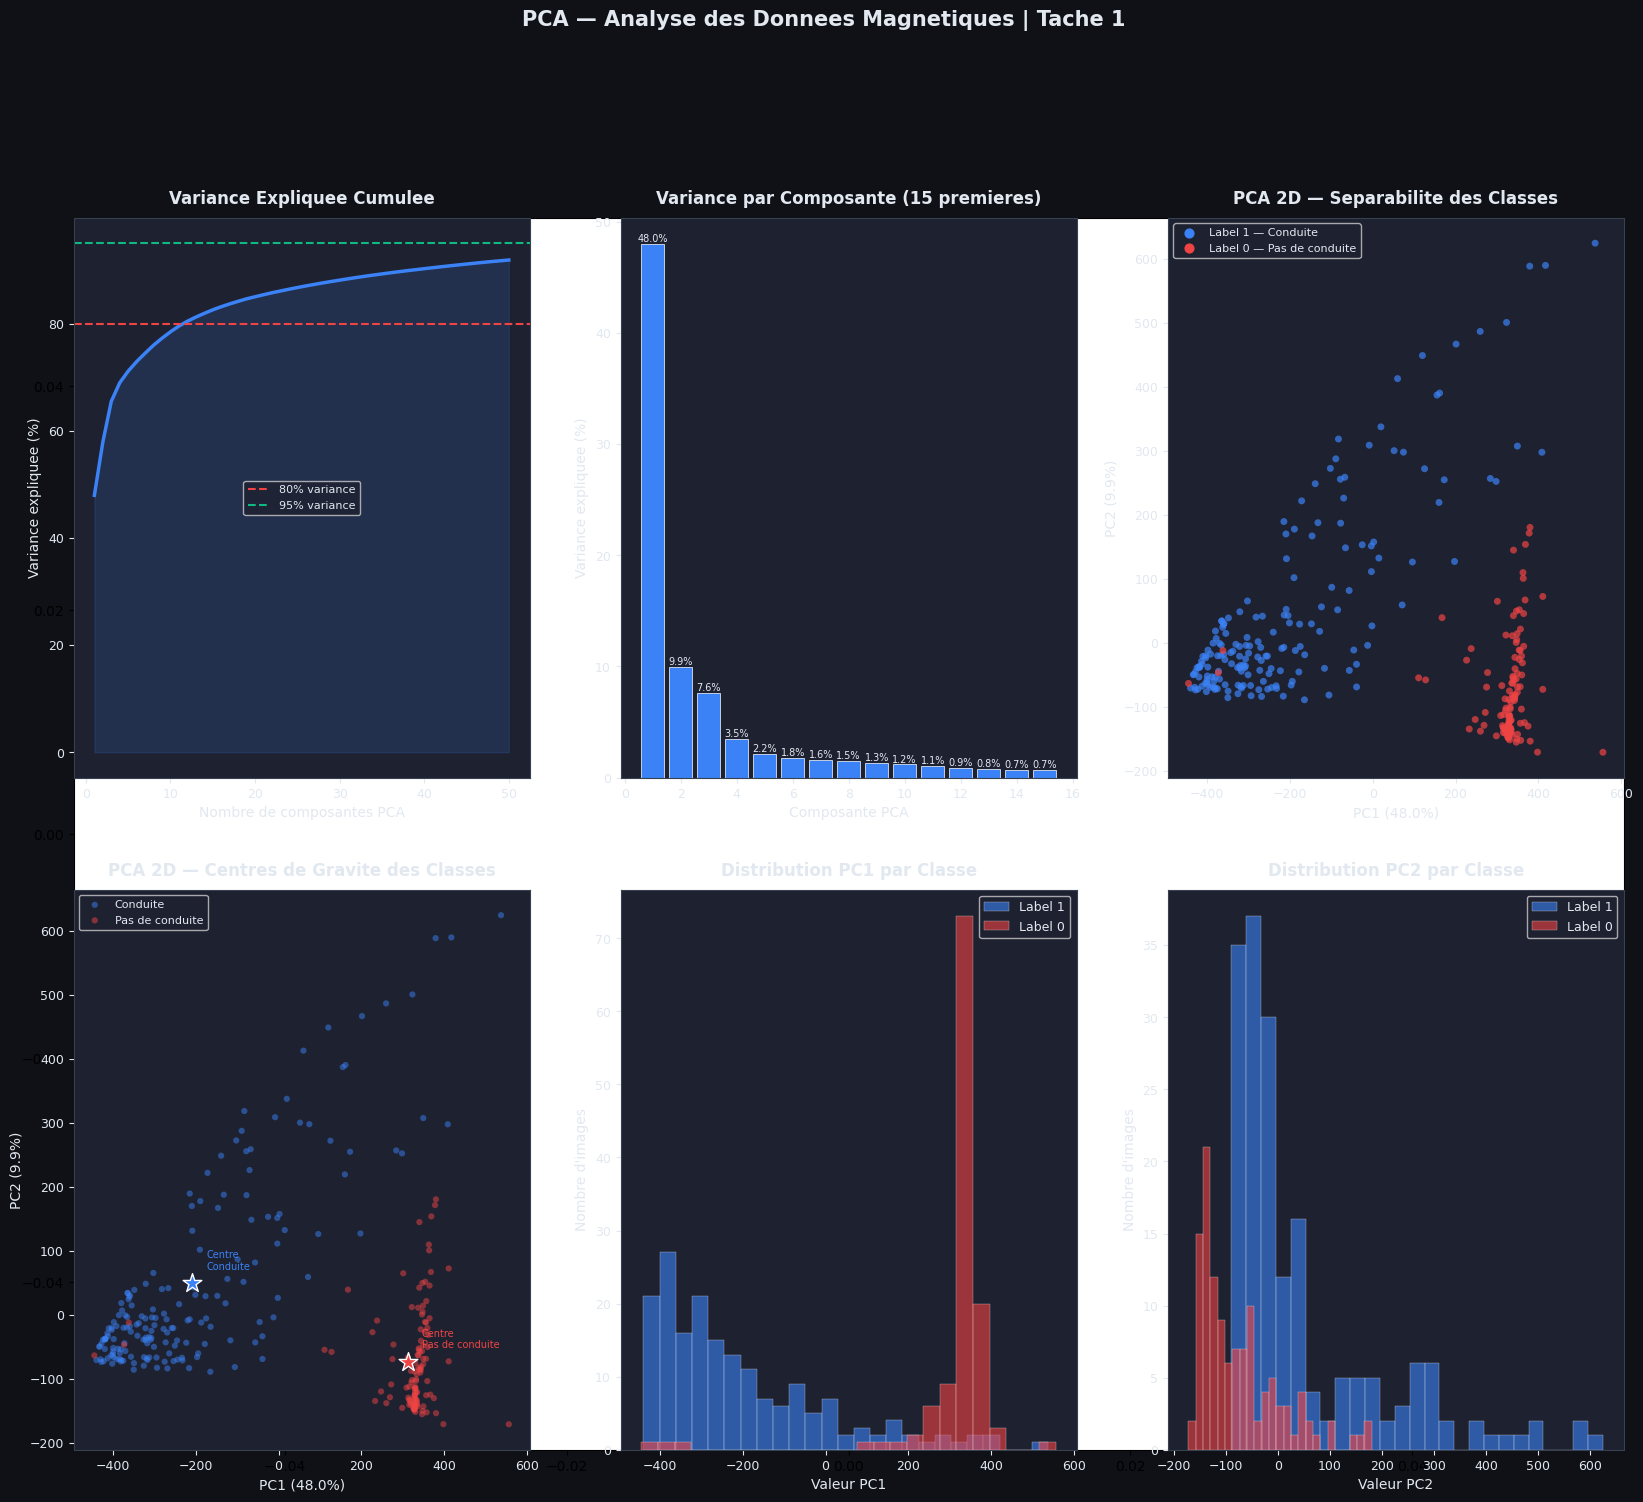


--- CONCLUSION PCA ---
Variance expliquee par PC1+PC2 : 57.9%
Distance entre centres de classe (PC1+PC2) : 535.34
=> Les classes sont bien separees en PCA : le CNN devrait bien fonctionner.


In [2]:
import pandas as pd
import numpy as np
import os
import torch
import matplotlib
import matplotlib.pyplot as plt
import cv2
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset

# ============================================================
# CONFIGURATION
# ============================================================
DATA_DIR   = "Data_SNDT"
CSV_PATH   = os.path.join(DATA_DIR, "pipe_detection_label.csv")
IMG_SIZE   = (224, 224)
SEED       = 42
N_SAMPLES  = 300   # On prend 300 images pour la PCA (sinon trop long)

# ============================================================
# PREPROCESSING (même fonction que dans 02_preprocessing.py)
# ============================================================
def preprocess_npz(file_path, img_size=IMG_SIZE):
    data = np.load(file_path)['data'].astype(np.float32)
    data = np.nan_to_num(data, nan=0.0)
    for c in range(data.shape[2]):
        canal = data[:, :, c]
        c_min, c_max = canal.min(), canal.max()
        if c_max - c_min > 0:
            data[:, :, c] = (canal - c_min) / (c_max - c_min)
        else:
            data[:, :, c] = 0.0
    data_resized = cv2.resize(data, (img_size[1], img_size[0]), interpolation=cv2.INTER_LINEAR)
    return data_resized   # (224, 224, 4) — on garde numpy ici pour la PCA

# ============================================================
# ETAPE 1 — Chargement d'un sous-ensemble pour la PCA
# ============================================================
df = pd.read_csv(CSV_PATH, sep=';')

# On prend N_SAMPLES images en gardant le ratio 60/40
df_1 = df[df['label'] == 1].sample(int(N_SAMPLES * 0.60), random_state=SEED)
df_0 = df[df['label'] == 0].sample(int(N_SAMPLES * 0.40), random_state=SEED)
df_sample = pd.concat([df_1, df_0]).reset_index(drop=True)

print(f"Echantillon PCA : {len(df_sample)} images")
print(f"Label=1 : {df_sample['label'].sum()} | Label=0 : {(df_sample['label']==0).sum()}")

# ============================================================
# ETAPE 2 — Chargement et aplatissement des images
# ============================================================
# La PCA a besoin d'un tableau 2D : (n_images, n_features)
# Chaque image (224, 224, 4) devient un vecteur de 200 704 valeurs

print("\nChargement des images pour la PCA...")
X = []
y = []

for i, row in df_sample.iterrows():
    file_path = os.path.join(DATA_DIR, row['field_file'])
    img = preprocess_npz(file_path)          # (224, 224, 4)
    X.append(img.flatten())                   # → vecteur 200 704
    y.append(row['label'])
    if len(X) % 50 == 0:
        print(f"  {len(X)}/{len(df_sample)} images chargées...")

X = np.array(X)   # (300, 200704)
y = np.array(y)   # (300,)

print(f"\nShape de X : {X.shape}  => ({len(X)} images, {X.shape[1]} features)")

# ============================================================
# ETAPE 3 — Normalisation avant PCA
# ============================================================
# La PCA est sensible aux échelles — on centre et réduit les données
# StandardScaler : moyenne=0, écart-type=1 pour chaque feature

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Après StandardScaler — mean≈0 : {X_scaled.mean():.4f}, std≈1 : {X_scaled.std():.4f}")

# ============================================================
# ETAPE 4 — PCA en 2D et 3D
# ============================================================
# n_components=50 : on garde 50 composantes principales d'abord
# pour analyser la variance expliquée

pca_full = PCA(n_components=50, random_state=SEED)
X_pca_full = pca_full.fit_transform(X_scaled)

variance_cumulee = np.cumsum(pca_full.explained_variance_ratio_) * 100
print(f"\nVariance expliquée par les 2 premières composantes  : {variance_cumulee[1]:.1f}%")
print(f"Variance expliquée par les 10 premières composantes : {variance_cumulee[9]:.1f}%")
print(f"Variance expliquée par les 50 premières composantes : {variance_cumulee[49]:.1f}%")

# PCA 2D pour visualisation
pca_2d = PCA(n_components=2, random_state=SEED)
X_2d = pca_2d.fit_transform(X_scaled)

# PCA 3D pour visualisation
pca_3d = PCA(n_components=3, random_state=SEED)
X_3d = pca_3d.fit_transform(X_scaled)

# ============================================================
# ETAPE 5 — VISUALISATIONS
# ============================================================
fig = plt.figure(figsize=(20, 16))
fig.patch.set_facecolor('#0f1117')
BG    = '#1e2130'
TEXT  = '#e2e8f0'
C1    = '#3b82f6'   # Bleu  = label 1 (conduite)
C0    = '#ef4444'   # Rouge = label 0 (pas de conduite)

def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, color=TEXT, fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(colors=TEXT, labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#374151')
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)

colors = [C1 if label == 1 else C0 for label in y]
legend_elements = [
    plt.scatter([], [], c=C1, s=40, label='Label 1 — Conduite présente'),
    plt.scatter([], [], c=C0, s=40, label='Label 0 — Pas de conduite'),
]

# --- GRAPHIQUE 1 : Variance expliquée cumulée ---
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(range(1, 51), variance_cumulee, color=C1, linewidth=2.5)
ax1.axhline(80, color=C0,    linestyle='--', linewidth=1.5, label='80% variance')
ax1.axhline(95, color='#10b981', linestyle='--', linewidth=1.5, label='95% variance')
ax1.fill_between(range(1, 51), variance_cumulee, alpha=0.15, color=C1)
ax1.legend(facecolor=BG, labelcolor=TEXT, fontsize=8)
style_ax(ax1, 'Variance Expliquee Cumulee')
ax1.set_xlabel('Nombre de composantes PCA')
ax1.set_ylabel('Variance expliquee (%)')

# --- GRAPHIQUE 2 : Variance par composante (barre) ---
ax2 = fig.add_subplot(2, 3, 2)
variances = pca_full.explained_variance_ratio_[:15] * 100
ax2.bar(range(1, 16), variances, color=C1, edgecolor='white', linewidth=0.5)
for i, v in enumerate(variances):
    ax2.text(i+1, v+0.2, f'{v:.1f}%', ha='center', color=TEXT, fontsize=7)
style_ax(ax2, 'Variance par Composante (15 premieres)')
ax2.set_xlabel('Composante PCA')
ax2.set_ylabel('Variance expliquee (%)')

# --- GRAPHIQUE 3 : PCA 2D ---
ax3 = fig.add_subplot(2, 3, 3)
scatter = ax3.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=colors, s=25, alpha=0.7, edgecolors='none'
)
ax3.scatter([], [], c=C1, s=40, label='Label 1 — Conduite')
ax3.scatter([], [], c=C0, s=40, label='Label 0 — Pas de conduite')
ax3.legend(facecolor=BG, labelcolor=TEXT, fontsize=8)
style_ax(ax3, 'PCA 2D — Separabilite des Classes')
ax3.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax3.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')

# --- GRAPHIQUE 4 : PCA 2D avec density (KDE) ---
ax4 = fig.add_subplot(2, 3, 4)
for label_val, color, name in [(1, C1, 'Conduite'), (0, C0, 'Pas de conduite')]:
    mask = y == label_val
    ax4.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, s=20, alpha=0.5,
                edgecolors='none', label=name)
    # Centre de gravité de chaque classe
    cx, cy = X_2d[mask, 0].mean(), X_2d[mask, 1].mean()
    ax4.scatter(cx, cy, c=color, s=200, marker='*', edgecolors='white', linewidth=1, zorder=5)
    ax4.annotate(f'Centre\n{name}', (cx, cy), textcoords='offset points',
                 xytext=(10, 10), color=color, fontsize=7)
ax4.legend(facecolor=BG, labelcolor=TEXT, fontsize=8)
style_ax(ax4, 'PCA 2D — Centres de Gravite des Classes')
ax4.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax4.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')

# --- GRAPHIQUE 5 : Distribution PC1 par classe ---
ax5 = fig.add_subplot(2, 3, 5)
for label_val, color, name in [(1, C1, 'Label 1'), (0, C0, 'Label 0')]:
    mask = y == label_val
    ax5.hist(X_2d[mask, 0], bins=25, color=color, alpha=0.6,
             edgecolor='white', linewidth=0.3, label=name)
ax5.legend(facecolor=BG, labelcolor=TEXT, fontsize=9)
style_ax(ax5, 'Distribution PC1 par Classe')
ax5.set_xlabel('Valeur PC1')
ax5.set_ylabel('Nombre d\'images')

# --- GRAPHIQUE 6 : Distribution PC2 par classe ---
ax6 = fig.add_subplot(2, 3, 6)
for label_val, color, name in [(1, C1, 'Label 1'), (0, C0, 'Label 0')]:
    mask = y == label_val
    ax6.hist(X_2d[mask, 1], bins=25, color=color, alpha=0.6,
             edgecolor='white', linewidth=0.3, label=name)
ax6.legend(facecolor=BG, labelcolor=TEXT, fontsize=9)
style_ax(ax6, 'Distribution PC2 par Classe')
ax6.set_xlabel('Valeur PC2')
ax6.set_ylabel('Nombre d\'images')

fig.suptitle('PCA — Analyse des Donnees Magnetiques | Tache 1',
             color=TEXT, fontsize=15, fontweight='bold', y=1.01)

plt.show()

# ============================================================
# ETAPE 6 — Conclusion PCA
# ============================================================
print("\n--- CONCLUSION PCA ---")
print(f"Variance expliquee par PC1+PC2 : {variance_cumulee[1]:.1f}%")

# Distance entre les centres des deux classes
centre_1 = X_2d[y == 1].mean(axis=0)
centre_0 = X_2d[y == 0].mean(axis=0)
distance = np.linalg.norm(centre_1 - centre_0)
print(f"Distance entre centres de classe (PC1+PC2) : {distance:.2f}")

if distance > 5:
    print("=> Les classes sont bien separees en PCA : le CNN devrait bien fonctionner.")
else:
    print("=> Les classes se chevauchent en PCA : le CNN devra apprendre des patterns complexes.")

CNN

In [7]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR   = "Data_SNDT"
CSV_PATH   = os.path.join(DATA_DIR, "pipe_detection_label.csv")
IMG_SIZE   = (64, 64)      # ← 64x64 pour la vitesse
BATCH_SIZE = 32
EPOCHS     = 100
LR         = 1e-3
SEED       = 42
MODEL_PATH = "task1_model.pth"
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

Device : cpu


In [8]:
def preprocess_npz(file_path, img_size=IMG_SIZE):
    data = np.load(file_path)['data'].astype(np.float32)
    data = np.nan_to_num(data, nan=0.0)
    for c in range(data.shape[2]):
        canal = data[:, :, c]
        c_min, c_max = canal.min(), canal.max()
        if c_max - c_min > 0:
            data[:, :, c] = (canal - c_min) / (c_max - c_min)
        else:
            data[:, :, c] = 0.0
    data_resized = cv2.resize(data, (img_size[1], img_size[0]), interpolation=cv2.INTER_LINEAR)
    return torch.tensor(data_resized).permute(2, 0, 1)

class PipelineDataset(Dataset):
    def __init__(self, dataframe, data_dir, img_size=IMG_SIZE):
        self.labels = []
        self.images = []
        print(f"Chargement de {len(dataframe)} images en RAM...")
        for i, row in dataframe.iterrows():
            file_path = os.path.join(data_dir, row['field_file'])
            self.images.append(preprocess_npz(file_path, img_size))
            self.labels.append(row['label'])
            if len(self.images) % 200 == 0:
                print(f"  {len(self.images)}/{len(dataframe)} chargées...")
        print("Chargement terminé !")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], torch.tensor(self.labels[idx], dtype=torch.long)

In [9]:
df = pd.read_csv(CSV_PATH, sep=';')
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df['label'])
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label'])

train_dataset = PipelineDataset(train_df, DATA_DIR)
val_dataset   = PipelineDataset(val_df,   DATA_DIR)
test_dataset  = PipelineDataset(test_df,  DATA_DIR)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("DataLoaders prêts !")

Chargement de 2054 images en RAM...
  200/2054 chargées...
  400/2054 chargées...
  600/2054 chargées...
  800/2054 chargées...
  1000/2054 chargées...
  1200/2054 chargées...
  1400/2054 chargées...
  1600/2054 chargées...
  1800/2054 chargées...
  2000/2054 chargées...
Chargement terminé !
Chargement de 440 images en RAM...
  200/440 chargées...
  400/440 chargées...
Chargement terminé !
Chargement de 441 images en RAM...
  200/441 chargées...
  400/441 chargées...
Chargement terminé !
DataLoaders prêts !


In [10]:
class PipelineCNN(nn.Module):
    def __init__(self):
        super(PipelineCNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        return self.classifier(x)

model     = PipelineCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
print(f"Paramètres : {sum(p.numel() for p in model.parameters()):,}")

Paramètres : 102,370


In [11]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_recall': [], 'val_f1': []}
best_val_loss = float('inf')

print(f"{'Epoch':<8} {'Train Loss':<12} {'Val Loss':<12} {'Train Acc':<12} {'Val Acc':<12} {'Val Recall':<12} {'Val F1'}")
print("-" * 80)

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * images.size(0)
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += images.size(0)
    train_loss /= train_total
    train_acc   = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_loss    += loss.item() * images.size(0)
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_loss  /= val_total
    val_acc    = val_correct / val_total
    val_recall = recall_score(all_labels, all_preds, zero_division=0)
    val_f1     = f1_score(all_labels, all_preds, zero_division=0)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        saved = " <= sauvegardé"
    else:
        saved = ""

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_recall'].append(val_recall)
    history['val_f1'].append(val_f1)

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:<8} {train_loss:<12.4f} {val_loss:<12.4f} {train_acc:<12.3f} {val_acc:<12.3f} {val_recall:<12.3f} {val_f1:.3f}{saved}")

Epoch    Train Loss   Val Loss     Train Acc    Val Acc      Val Recall   Val F1
--------------------------------------------------------------------------------
1        0.1350       0.0898       0.965        0.973        1.000        0.978 <= sauvegardé
5        0.0383       0.0293       0.989        0.993        1.000        0.994 <= sauvegardé
10       0.0416       0.0148       0.987        0.995        1.000        0.996
15       0.0172       0.0031       0.996        1.000        1.000        1.000 <= sauvegardé
20       0.0050       0.0016       0.999        1.000        1.000        1.000
25       0.0041       0.0074       0.999        0.998        1.000        0.998
30       0.0067       0.0168       0.999        0.998        1.000        0.998
35       0.0034       0.0108       0.999        0.998        1.000        0.998
40       0.0019       0.0062       1.000        0.998        1.000        0.998
45       0.0020       0.0066       1.000        0.998        1.000        0.

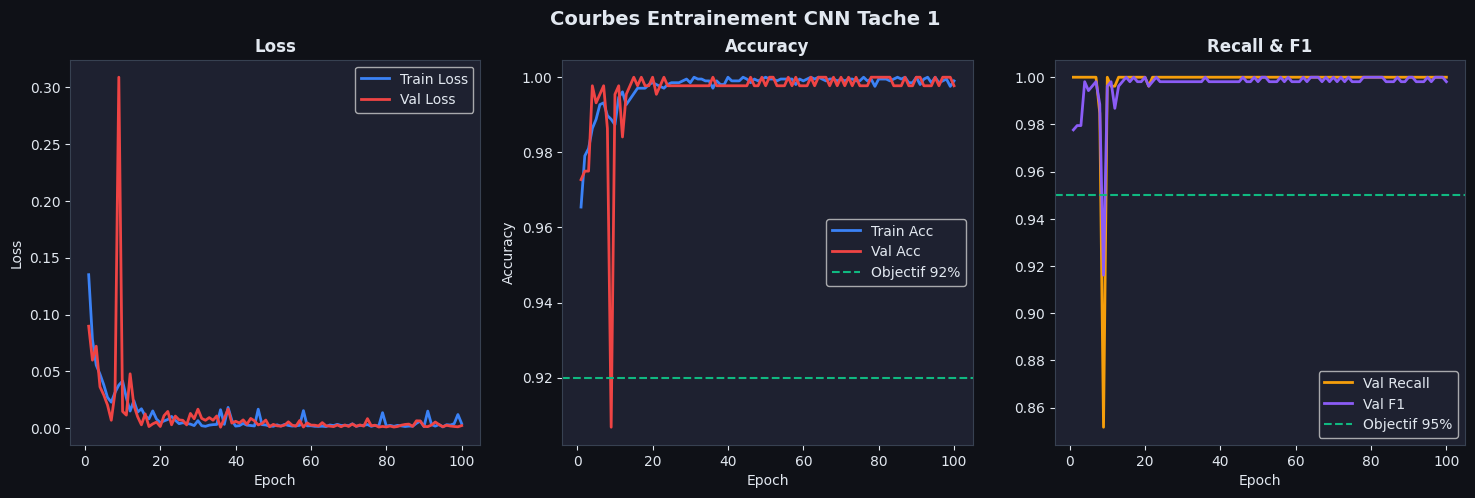

In [12]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f1117')
BG, TEXT = '#1e2130', '#e2e8f0'

def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, color=TEXT, fontsize=12, fontweight='bold')
    ax.tick_params(colors=TEXT)
    for spine in ax.spines.values(): spine.set_edgecolor('#374151')
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.legend(facecolor=BG, labelcolor=TEXT)

axes[0].plot(epochs_range, history['train_loss'], color='#3b82f6', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   color='#ef4444', label='Val Loss',   linewidth=2)
style_ax(axes[0], 'Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(epochs_range, history['train_acc'], color='#3b82f6', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'],   color='#ef4444', label='Val Acc',   linewidth=2)
axes[1].axhline(0.92, color='#10b981', linestyle='--', linewidth=1.5, label='Objectif 92%')
style_ax(axes[1], 'Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')

axes[2].plot(epochs_range, history['val_recall'], color='#f59e0b', label='Val Recall', linewidth=2)
axes[2].plot(epochs_range, history['val_f1'],     color='#8b5cf6', label='Val F1',     linewidth=2)
axes[2].axhline(0.95, color='#10b981', linestyle='--', linewidth=1.5, label='Objectif 95%')
style_ax(axes[2], 'Recall & F1')
axes[2].set_xlabel('Epoch')

fig.suptitle('Courbes Entrainement CNN Tache 1', color=TEXT, fontsize=14, fontweight='bold')
plt.show()

Accuracy : 0.9955  (objectif > 0.92)
Recall   : 1.0000  (objectif > 0.95)
F1-Score : 0.9962


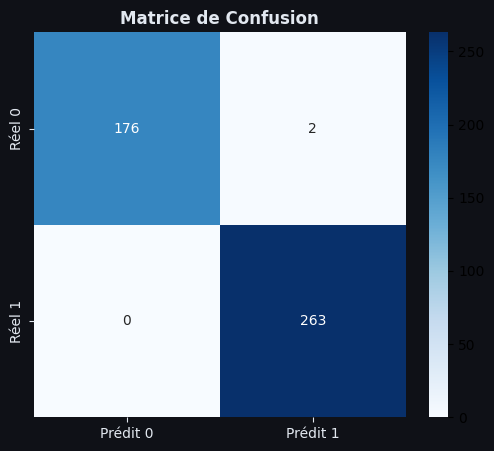

In [13]:
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

acc    = accuracy_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds, zero_division=0)
f1     = f1_score(all_labels, all_preds, zero_division=0)
print(f"Accuracy : {acc:.4f}  (objectif > 0.92)")
print(f"Recall   : {recall:.4f}  (objectif > 0.95)")
print(f"F1-Score : {f1:.4f}")

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1e2130')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
ax.set_title('Matrice de Confusion', color='#e2e8f0', fontweight='bold')
ax.tick_params(colors='#e2e8f0')
plt.show()

TASK 2

Dataset complet       : 2935 échantillons
Dataset Tâche 2 (label=1) : 1751 échantillons
NaN dans width_m      : 0

--- STATISTIQUES WIDTH_M ---
count    1751.000000
mean       36.934272
std        33.576720
min         2.010000
25%        11.125000
50%        25.640000
75%        54.750000
max       154.840000
Name: width_m, dtype: float64


C:\Users\aissa\AppData\Local\Temp\ipykernel_35516\1158380519.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_b, labels=types, patch_artist=True,
C:\Users\aissa\AppData\Local\Temp\ipykernel_35516\1158380519.py:75: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax3.boxplot(data_c, labels=covs, patch_artist=True,
C:\Users\aissa\AppData\Local\Temp\ipykernel_35516\1158380519.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp3 = ax4.boxplot(data_s, labels=shapes, patch_artist=True,


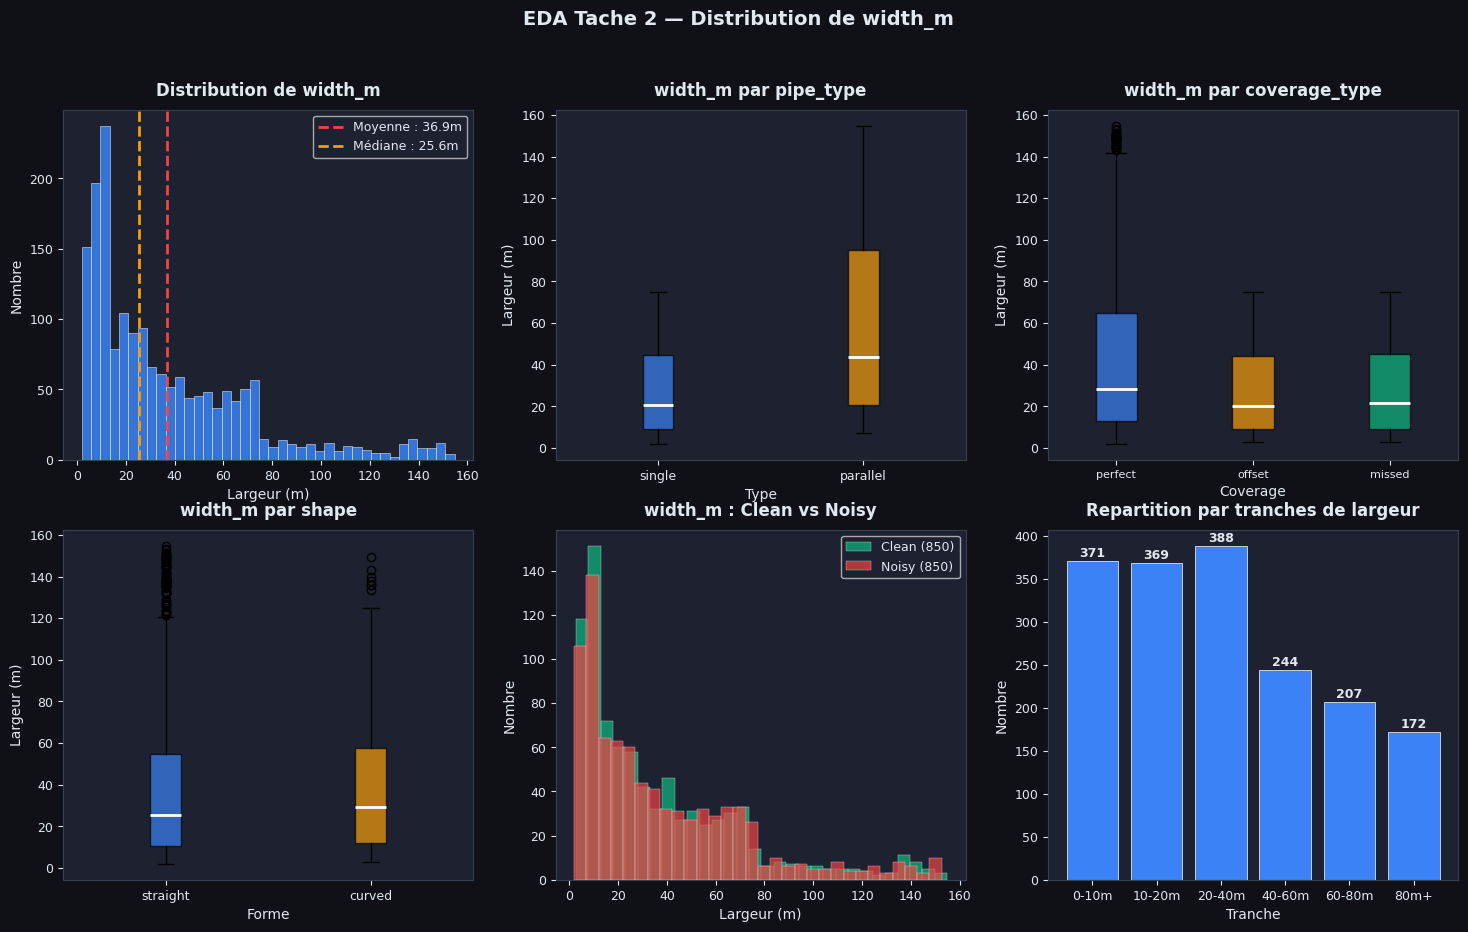


--- CONCLUSION EDA TACHE 2 ---
Min   : 2.01m
Max   : 154.84m
Mean  : 36.93m
Std   : 33.58m
Objectif MAE < 1m — le modele doit etre tres precis.


In [14]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIGURATION
# ============================================================
DATA_DIR = "Data_SNDT"
CSV_PATH = os.path.join(DATA_DIR, "pipe_detection_label.csv")

# ============================================================
# CHARGEMENT — uniquement label=1 pour la tâche 2
# ============================================================
df      = pd.read_csv(CSV_PATH, sep=';')
df_task2 = df[df['label'] == 1].reset_index(drop=True)

print(f"Dataset complet       : {len(df)} échantillons")
print(f"Dataset Tâche 2 (label=1) : {len(df_task2)} échantillons")
print(f"NaN dans width_m      : {df_task2['width_m'].isna().sum()}")

# ============================================================
# STATISTIQUES DE BASE
# ============================================================
print("\n--- STATISTIQUES WIDTH_M ---")
print(df_task2['width_m'].describe())

# ============================================================
# VISUALISATIONS
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0f1117')
BG, TEXT = '#1e2130', '#e2e8f0'
C1 = '#3b82f6'
C2 = '#f59e0b'
C3 = '#10b981'

def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, color=TEXT, fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(colors=TEXT, labelsize=9)
    for spine in ax.spines.values(): spine.set_edgecolor('#374151')
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)

# --- Graphique 1 : Distribution de width_m ---
ax1 = axes[0, 0]
ax1.hist(df_task2['width_m'], bins=40, color=C1, edgecolor='white', linewidth=0.4, alpha=0.85)
ax1.axvline(df_task2['width_m'].mean(),   color='#ef4444', linestyle='--', linewidth=2, label=f"Moyenne : {df_task2['width_m'].mean():.1f}m")
ax1.axvline(df_task2['width_m'].median(), color=C2,        linestyle='--', linewidth=2, label=f"Médiane : {df_task2['width_m'].median():.1f}m")
ax1.legend(facecolor=BG, labelcolor=TEXT, fontsize=9)
style_ax(ax1, 'Distribution de width_m')
ax1.set_xlabel('Largeur (m)')
ax1.set_ylabel('Nombre')

# --- Graphique 2 : Boxplot par pipe_type ---
ax2 = axes[0, 1]
types  = df_task2['pipe_type'].dropna().unique()
data_b = [df_task2[df_task2['pipe_type'] == t]['width_m'].dropna().values for t in types]
bp = ax2.boxplot(data_b, labels=types, patch_artist=True,
                 medianprops=dict(color='white', linewidth=2))
colors_box = [C1, C2, C3]
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
style_ax(ax2, 'width_m par pipe_type')
ax2.set_xlabel('Type')
ax2.set_ylabel('Largeur (m)')

# --- Graphique 3 : Boxplot par coverage_type ---
ax3 = axes[0, 2]
covs   = df_task2['coverage_type'].dropna().unique()
data_c = [df_task2[df_task2['coverage_type'] == c]['width_m'].dropna().values for c in covs]
bp2 = ax3.boxplot(data_c, labels=covs, patch_artist=True,
                  medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp2['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
style_ax(ax3, 'width_m par coverage_type')
ax3.set_xlabel('Coverage')
ax3.set_ylabel('Largeur (m)')
ax3.tick_params(axis='x', labelsize=8)

# --- Graphique 4 : width_m par shape ---
ax4 = axes[1, 0]
shapes  = df_task2['shape'].dropna().unique()
data_s  = [df_task2[df_task2['shape'] == s]['width_m'].dropna().values for s in shapes]
bp3 = ax4.boxplot(data_s, labels=shapes, patch_artist=True,
                  medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp3['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
style_ax(ax4, 'width_m par shape')
ax4.set_xlabel('Forme')
ax4.set_ylabel('Largeur (m)')

# --- Graphique 5 : width_m Clean vs Noisy ---
ax5 = axes[1, 1]
noisy_vals = df_task2[df_task2['noisy'] == True]['width_m'].dropna()
clean_vals = df_task2[df_task2['noisy'] == False]['width_m'].dropna()
ax5.hist(clean_vals, bins=30, color=C3,        alpha=0.7, edgecolor='white', linewidth=0.3, label=f'Clean ({len(clean_vals)})')
ax5.hist(noisy_vals, bins=30, color='#ef4444', alpha=0.7, edgecolor='white', linewidth=0.3, label=f'Noisy ({len(noisy_vals)})')
ax5.legend(facecolor=BG, labelcolor=TEXT, fontsize=9)
style_ax(ax5, 'width_m : Clean vs Noisy')
ax5.set_xlabel('Largeur (m)')
ax5.set_ylabel('Nombre')

# --- Graphique 6 : Répartition par tranches ---
ax6 = axes[1, 2]
bins_tranches = [0, 10, 20, 40, 60, 80, 160]
labels_t      = ['0-10m', '10-20m', '20-40m', '40-60m', '60-80m', '80m+']
counts_t      = pd.cut(df_task2['width_m'], bins=bins_tranches, labels=labels_t).value_counts().sort_index()
bars = ax6.bar(counts_t.index, counts_t.values, color=C1, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, counts_t.values):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', color=TEXT, fontsize=9, fontweight='bold')
style_ax(ax6, 'Repartition par tranches de largeur')
ax6.set_xlabel('Tranche')
ax6.set_ylabel('Nombre')

fig.suptitle('EDA Tache 2 — Distribution de width_m', color=TEXT, fontsize=14, fontweight='bold')
plt.show()

# ============================================================
# CONCLUSION
# ============================================================
print("\n--- CONCLUSION EDA TACHE 2 ---")
print(f"Min   : {df_task2['width_m'].min():.2f}m")
print(f"Max   : {df_task2['width_m'].max():.2f}m")
print(f"Mean  : {df_task2['width_m'].mean():.2f}m")
print(f"Std   : {df_task2['width_m'].std():.2f}m")
print(f"Objectif MAE < 1m — le modele doit etre tres precis.")

regression

In [39]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import cv2
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURATION
# ============================================================
DATA_DIR   = "Data_SNDT"
CSV_PATH   = os.path.join(DATA_DIR, "pipe_detection_label.csv")
SEED       = 42
MODEL_PATH = "task2_model.pth"
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device : {DEVICE}")

# ============================================================
# EXTRACTION DE FEATURES PHYSIQUES
# ============================================================
def extract_features(file_path):
    """
    Extrait des features physiques depuis un fichier NPZ.
    Ces features décrivent directement la forme du signal magnétique
    ce qui est beaucoup plus pertinent pour prédire width_m.
    """
    data = np.load(file_path)['data'].astype(np.float32)
    data = np.nan_to_num(data, nan=0.0)

    # Séparer les 4 canaux
    Bx   = data[:, :, 0]
    By   = data[:, :, 1]
    Bz   = data[:, :, 2]
    Norm = data[:, :, 3]

    # Masque des pixels valides (non-NaN à l'origine)
    mask = Norm > 0

    features = {}

    # --- Features globales sur Norm ---
    norm_valid = Norm[mask]
    features['norm_max']    = norm_valid.max()
    features['norm_mean']   = norm_valid.mean()
    features['norm_std']    = norm_valid.std()
    features['norm_median'] = np.median(norm_valid)

    # --- Features globales sur Bz (vertical) ---
    bz_valid = Bz[mask]
    features['bz_max']    = bz_valid.max()
    features['bz_mean']   = bz_valid.mean()
    features['bz_std']    = bz_valid.std()
    features['bz_range']  = bz_valid.max() - bz_valid.min()

    # --- Features globales sur Bx ---
    bx_valid = Bx[mask]
    features['bx_max']   = bx_valid.max()
    features['bx_std']   = bx_valid.std()
    features['bx_range'] = bx_valid.max() - bx_valid.min()

    # --- Features globales sur By ---
    by_valid = By[mask]
    features['by_max']   = by_valid.max()
    features['by_std']   = by_valid.std()
    features['by_range'] = by_valid.max() - by_valid.min()

    # --- Dimensions spatiales de la carte ---
    # Nombre de pixels valides et dimensions
    features['n_valid_pixels'] = mask.sum()
    features['height']         = data.shape[0]
    features['width_pixels']   = data.shape[1]
    features['aspect_ratio']   = data.shape[0] / (data.shape[1] + 1e-6)

    # --- Profil moyen sur l'axe court (largeur physique) ---
    # On prend le profil de Norm sur chaque colonne
    col_means = Norm.mean(axis=0)   # moyenne sur les lignes
    row_means = Norm.mean(axis=1)   # moyenne sur les colonnes

    # Largeur du profil au-dessus du seuil (50% du max)
    threshold = col_means.max() * 0.5
    above     = col_means > threshold
    features['profile_width_cols'] = above.sum()

    threshold2 = row_means.max() * 0.5
    above2     = row_means > threshold2
    features['profile_width_rows'] = above2.sum()

    # --- Gradient spatial (mesure de la variation du champ) ---
    grad_x = np.gradient(Norm, axis=1)
    grad_y = np.gradient(Norm, axis=0)
    grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)
    features['grad_mean'] = grad_magnitude[mask].mean()
    features['grad_max']  = grad_magnitude[mask].max()

    # --- Ratio pixels valides / total ---
    features['coverage_ratio'] = mask.mean()

    # --- Dimensions physiques en mètres (1 pixel = 0.2m) ---
    features['height_m']       = data.shape[0] * 0.2
    features['width_pixels_m'] = data.shape[1] * 0.2

    return list(features.values())

Device : cpu


In [40]:
# ============================================================
# CHARGEMENT ET EXTRACTION DES FEATURES
# ============================================================
df       = pd.read_csv(CSV_PATH, sep=';')
df_task2 = df[df['label'] == 1].reset_index(drop=True)
print(f"Echantillons tâche 2 : {len(df_task2)}")

print("Extraction des features physiques...")
X_list = []
y_list = []

for i, row in df_task2.iterrows():
    file_path = os.path.join(DATA_DIR, row['field_file'])
    feats = extract_features(file_path)
    X_list.append(feats)
    y_list.append(row['width_m'])
    if len(X_list) % 200 == 0:
        print(f"  {len(X_list)}/{len(df_task2)} fichiers traités...")

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)
print(f"Shape X : {X.shape}  => ({len(X)} échantillons, {X.shape[1]} features)")
print(f"Shape y : {y.shape}")

Echantillons tâche 2 : 1751
Extraction des features physiques...
  200/1751 fichiers traités...
  400/1751 fichiers traités...
  600/1751 fichiers traités...
  800/1751 fichiers traités...
  1000/1751 fichiers traités...
  1200/1751 fichiers traités...
  1400/1751 fichiers traités...
  1600/1751 fichiers traités...
Shape X : (1751, 25)  => (1751 échantillons, 25 features)
Shape y : (1751,)


In [41]:
# ============================================================
# SPLIT + NORMALISATION DES FEATURES
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print(f"Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")

# StandardScaler sur les features
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Conversion en tenseurs
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32)

# DataLoaders
train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
val_ds   = torch.utils.data.TensorDataset(X_val_t,   y_val_t)
test_ds  = torch.utils.data.TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

# ============================================================
# MODÈLE MLP (réseau de neurones sur les features)
# ============================================================
n_features = X_train.shape[1]

class WidthMLP(nn.Module):
    """
    MLP (Multi-Layer Perceptron) pour régression sur features physiques.
    Plus adapté qu'un CNN pour des features numériques extraites.
    """
    def __init__(self, n_features):
        super(WidthMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),         nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32),          nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

model     = WidthMLP(n_features).to(DEVICE)
criterion = nn.SmoothL1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
print(f"Paramètres MLP : {sum(p.numel() for p in model.parameters()):,}")

Train : 1225 | Val : 263 | Test : 263
Paramètres MLP : 13,697


In [42]:
# ============================================================
# ENTRAINEMENT
# ============================================================
EPOCHS  = 300
history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
best_val_loss = float('inf')

print(f"\n{'Epoch':<8} {'Train Loss':<12} {'Val Loss':<12} {'Train MAE':<12} {'Val MAE (m)'}")
print("-" * 60)

for epoch in range(1, EPOCHS + 1):

    model.train()
    train_preds, train_labels = [], []
    train_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out  = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
        train_preds.extend(out.detach().cpu().numpy())
        train_labels.extend(yb.cpu().numpy())

    train_loss /= len(train_ds)
    train_mae   = mean_absolute_error(train_labels, train_preds)

    model.eval()
    val_preds, val_labels = [], []
    val_loss = 0.0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out  = model(xb)
            loss = criterion(out, yb)
            val_loss += loss.item() * xb.size(0)
            val_preds.extend(out.cpu().numpy())
            val_labels.extend(yb.cpu().numpy())

    val_loss /= len(val_ds)
    val_mae   = mean_absolute_error(val_labels, val_preds)

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        saved = " <= sauvegardé"
    else:
        saved = ""

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_mae'].append(train_mae)
    history['val_mae'].append(val_mae)

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:<8} {train_loss:<12.4f} {val_loss:<12.4f} {train_mae:<12.2f} {val_mae:.2f}m{saved}")


Epoch    Train Loss   Val Loss     Train MAE    Val MAE (m)
------------------------------------------------------------
1        33.9456      29.5919      34.44        30.09m <= sauvegardé
5        9.5108       9.7510       9.99         10.23m <= sauvegardé
10       6.7931       6.3487       7.27         6.82m <= sauvegardé
15       5.8787       5.4039       6.35         5.87m
20       5.2149       4.1339       5.68         4.58m <= sauvegardé
25       4.8033       3.7524       5.27         4.21m <= sauvegardé
30       4.5328       3.5273       5.00         3.99m <= sauvegardé
35       4.4045       3.6610       4.87         4.11m
40       4.2492       3.7678       4.71         4.22m
45       4.3677       3.0251       4.83         3.48m
50       4.1423       2.8384       4.60         3.29m
55       4.1308       2.9127       4.59         3.36m
60       3.9754       2.6800       4.43         3.13m
65       3.8663       2.4836       4.33         2.93m <= sauvegardé
70       3.8557       

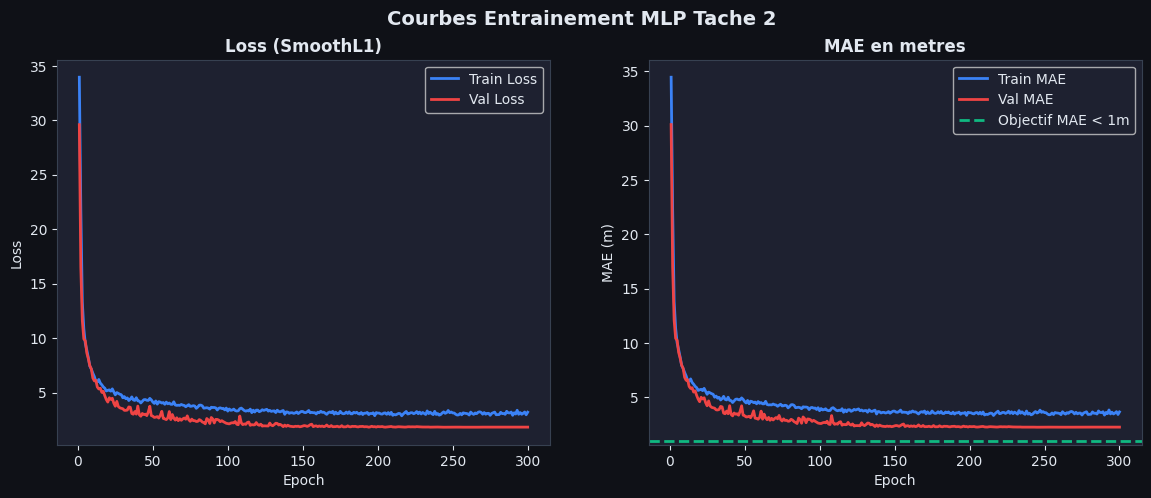

In [43]:
# ============================================================
# VISUALISATION COURBES
# ============================================================
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
BG, TEXT = '#1e2130', '#e2e8f0'

def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, color=TEXT, fontsize=12, fontweight='bold')
    ax.tick_params(colors=TEXT)
    for spine in ax.spines.values(): spine.set_edgecolor('#374151')
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.legend(facecolor=BG, labelcolor=TEXT)

axes[0].plot(epochs_range, history['train_loss'], color='#3b82f6', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   color='#ef4444', label='Val Loss',   linewidth=2)
style_ax(axes[0], 'Loss (SmoothL1)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(epochs_range, history['train_mae'], color='#3b82f6', label='Train MAE', linewidth=2)
axes[1].plot(epochs_range, history['val_mae'],   color='#ef4444', label='Val MAE',   linewidth=2)
axes[1].axhline(1.0, color='#10b981', linestyle='--', linewidth=2, label='Objectif MAE < 1m')
style_ax(axes[1], 'MAE en metres')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (m)')
fig.suptitle('Courbes Entrainement MLP Tache 2', color=TEXT, fontsize=14, fontweight='bold')
plt.show()


--- EVALUATION FINALE SUR LE TEST SET ---
MAE finale : 2.1985m  (objectif < 1m)


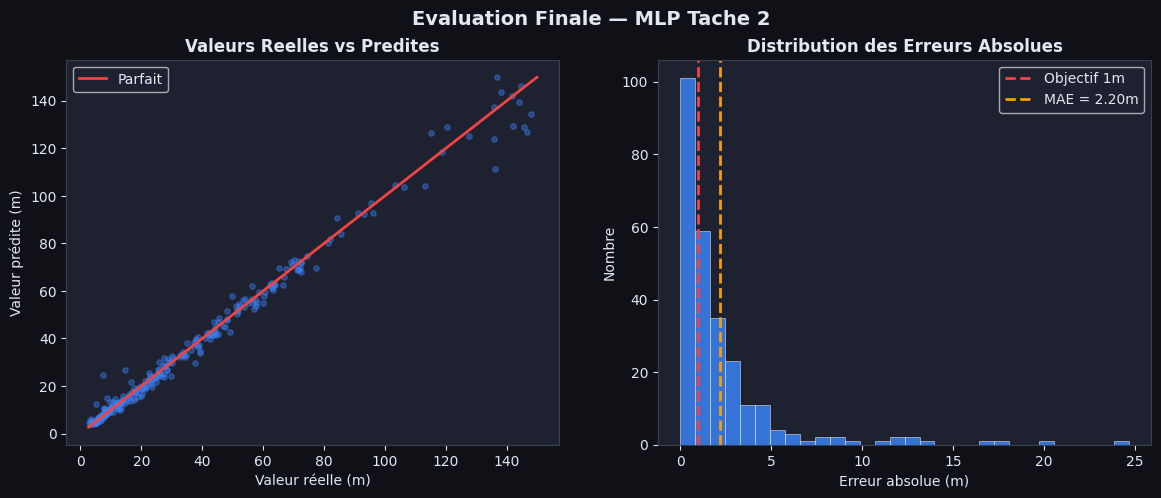

In [44]:
# ============================================================
# EVALUATION FINALE
# ============================================================
print("\n--- EVALUATION FINALE SUR LE TEST SET ---")
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        out = model(xb.to(DEVICE))
        all_preds.extend(out.cpu().numpy())
        all_labels.extend(yb.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
mae        = mean_absolute_error(all_labels, all_preds)
print(f"MAE finale : {mae:.4f}m  (objectif < 1m)")

# Graphiques évaluation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

axes[0].scatter(all_labels, all_preds, alpha=0.4, color='#3b82f6', s=15)
min_v, max_v = min(all_labels.min(), all_preds.min()), max(all_labels.max(), all_preds.max())
axes[0].plot([min_v, max_v], [min_v, max_v], color='#ef4444', linewidth=2, label='Parfait')
style_ax(axes[0], 'Valeurs Reelles vs Predites')
axes[0].set_xlabel('Valeur réelle (m)')
axes[0].set_ylabel('Valeur prédite (m)')

erreurs = np.abs(all_preds - all_labels)
axes[1].hist(erreurs, bins=30, color='#3b82f6', edgecolor='white', linewidth=0.4, alpha=0.85)
axes[1].axvline(1.0,           color='#ef4444', linestyle='--', linewidth=2, label='Objectif 1m')
axes[1].axvline(erreurs.mean(), color='#f59e0b', linestyle='--', linewidth=2, label=f'MAE = {erreurs.mean():.2f}m')
style_ax(axes[1], 'Distribution des Erreurs Absolues')
axes[1].set_xlabel('Erreur absolue (m)')
axes[1].set_ylabel('Nombre')
fig.suptitle('Evaluation Finale — MLP Tache 2', color=TEXT, fontsize=14, fontweight='bold')
plt.show()

Le scaler c'est le StandardScaler qu'on a utilisé dans notre code pour normaliser les features avant de les donner au MLP
**Pourquoi le sauvegarder ?**
Quand SKIPPER va utiliser `inference_task2.py` sur un nouveau fichier, il faut appliquer **exactement la même normalisation** qu'à l'entraînement. 
Par exemple le scaler a appris que `norm_max` a une moyenne de 150 et un std de 30 → il va soustraire 150 et diviser par 30. Si on ne sauvegarde pas ça, les nouvelles prédictions seront fausses car les features ne seront pas à la même échelle que pendant l'entraînement.


In [45]:
import joblib
joblib.dump(scaler, "task2_scaler.pkl")
print("Scaler sauvegardé !")

Scaler sauvegardé !


TASK 3

In [13]:
import pandas as pd
import os

df_t3 = pd.read_csv("Data_SNDT/data_tache_3.csv", sep=',')
print(df_t3.columns.tolist())
print(df_t3.head())
print(df_t3.shape)

['field_file', 'label', 'coverage_type', 'shape', 'noisy', 'pipe_type']
                                      field_file  label coverage_type  \
0  sample_00000_perfect_straight_clean_field.npz      1       perfect   
1  sample_00001_perfect_straight_clean_field.npz      1       perfect   
2  sample_00002_perfect_straight_clean_field.npz      1       perfect   
3  sample_00003_perfect_straight_clean_field.npz      1       perfect   
4  sample_00004_perfect_straight_clean_field.npz      1       perfect   

      shape  noisy pipe_type  
0  straight  False    single  
1  straight  False    single  
2  straight  False    single  
3  straight  False    single  
4  straight  False    single  
(4715, 6)


In [2]:
print(df_t3['label'].value_counts())
print(df_t3['coverage_type'].value_counts())

label
1    2829
0    1886
Name: count, dtype: int64
coverage_type
perfect    3915
offset      600
missed      200
Name: count, dtype: int64


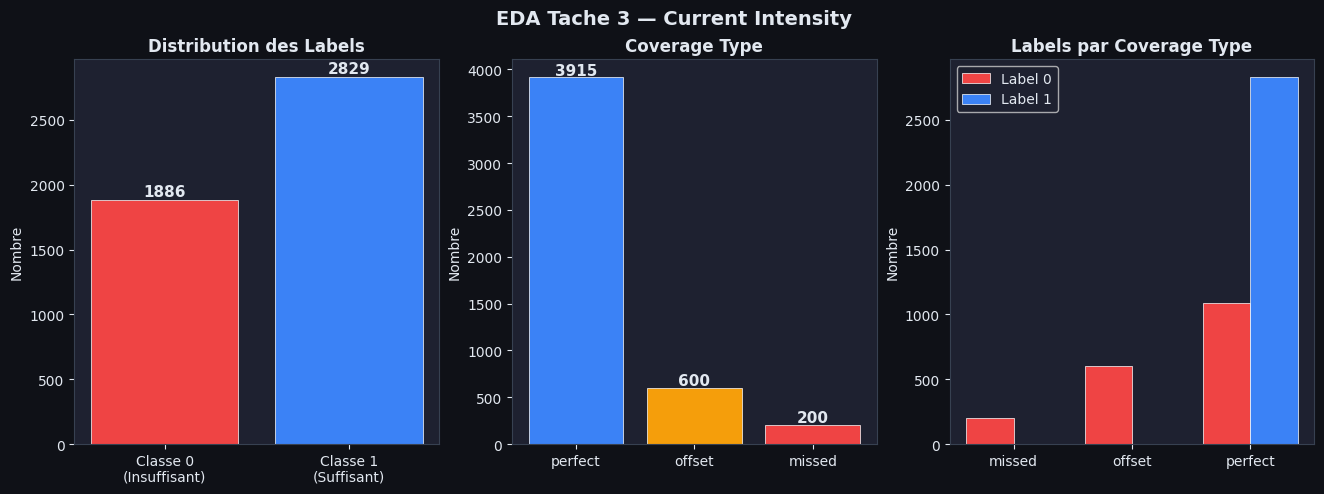

Total : 4715 | Label=1 : 2829 (60.0%) | Label=0 : 1886 (40.0%)
NaN : {'field_file': 0, 'label': 0, 'coverage_type': 0, 'shape': 0, 'noisy': 0, 'pipe_type': 0}


In [3]:
import pandas as pd
import os
import matplotlib.pyplot as plt

df_t3 = pd.read_csv("Data_SNDT/data_tache_3.csv", sep=',')

BG, TEXT = '#1e2130', '#e2e8f0'

def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, color=TEXT, fontsize=12, fontweight='bold')
    ax.tick_params(colors=TEXT)
    for spine in ax.spines.values(): spine.set_edgecolor('#374151')
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#0f1117')

# --- Distribution labels ---
counts = df_t3['label'].value_counts().sort_index()
axes[0].bar(['Classe 0\n(Insuffisant)', 'Classe 1\n(Suffisant)'],
            counts.values, color=['#ef4444', '#3b82f6'], edgecolor='white', linewidth=0.5)
for i, val in enumerate(counts.values):
    axes[0].text(i, val + 30, str(val), ha='center', color=TEXT, fontsize=11, fontweight='bold')
style_ax(axes[0], 'Distribution des Labels')
axes[0].set_ylabel('Nombre', color=TEXT)

# --- Coverage type ---
ct = df_t3['coverage_type'].value_counts()
axes[1].bar(ct.index, ct.values, color=['#3b82f6', '#f59e0b', '#ef4444'], edgecolor='white', linewidth=0.5)
for i, val in enumerate(ct.values):
    axes[1].text(i, val + 30, str(val), ha='center', color=TEXT, fontsize=11, fontweight='bold')
style_ax(axes[1], 'Coverage Type')
axes[1].set_ylabel('Nombre', color=TEXT)

# --- Label par coverage_type ---
ct_label = df_t3.groupby(['coverage_type', 'label']).size().unstack(fill_value=0)
x = range(len(ct_label))
axes[2].bar([i - 0.2 for i in x], ct_label[0], 0.4, label='Label 0', color='#ef4444', edgecolor='white', linewidth=0.5)
axes[2].bar([i + 0.2 for i in x], ct_label[1], 0.4, label='Label 1', color='#3b82f6', edgecolor='white', linewidth=0.5)
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(ct_label.index, color=TEXT)
axes[2].legend(facecolor=BG, labelcolor=TEXT)
style_ax(axes[2], 'Labels par Coverage Type')
axes[2].set_ylabel('Nombre', color=TEXT)

fig.suptitle('EDA Tache 3 — Current Intensity', color=TEXT, fontsize=14, fontweight='bold')
plt.show()

print(f"Total : {len(df_t3)} | Label=1 : {df_t3['label'].sum()} ({df_t3['label'].mean():.1%}) | Label=0 : {(df_t3['label']==0).sum()} ({(1-df_t3['label'].mean()):.1%})")
print(f"NaN : {df_t3.isnull().sum().to_dict()}")

In [26]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR   = "Data_SNDT"
CSV_PATH_3   = os.path.join(DATA_DIR, "data_tache_3.csv")
IMG_SIZE   = (64, 64)
BATCH_SIZE = 32
EPOCHS     = 100
LR         = 1e-3
SEED       = 42
MODEL_PATH = "task3_model.pth"
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device : {DEVICE}")

Device : cpu


pre process et dataset

In [27]:
def preprocess_npz(file_path, img_size=IMG_SIZE, augment=False):
    data = np.load(file_path)['data'].astype(np.float32)
    data = np.nan_to_num(data, nan=0.0)
    for c in range(data.shape[2]):
        canal = data[:, :, c]
        c_min, c_max = canal.min(), canal.max()
        if c_max - c_min > 0:
            data[:, :, c] = (canal - c_min) / (c_max - c_min)
        else:
            data[:, :, c] = 0.0
    data_resized = cv2.resize(data, (img_size[1], img_size[0]), interpolation=cv2.INTER_LINEAR)
    
    # Data augmentation uniquement sur le train
    if augment:
        if np.random.rand() > 0.5:
            data_resized = np.fliplr(data_resized)   # flip horizontal
        if np.random.rand() > 0.5:
            data_resized = np.flipud(data_resized)   # flip vertical
    
    return torch.tensor(data_resized.copy()).permute(2, 0, 1)

class PipelineDataset(Dataset):
    def __init__(self, dataframe, data_dir, img_size=IMG_SIZE, augment=False):
        self.images = []
        self.labels = []
        self.augment = augment
        print(f"Chargement de {len(dataframe)} images en RAM...")
        for _, row in dataframe.iterrows():
            file_path = os.path.join(data_dir, row['field_file'])
            self.images.append(preprocess_npz(file_path, img_size, augment=False))
            self.labels.append(row['label'])
            if len(self.images) % 300 == 0:
                print(f"  {len(self.images)}/{len(dataframe)} chargées...")
        print("Chargement terminé !")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        # Augmentation à la volée sur le train
        if self.augment:
            if np.random.rand() > 0.5:
                img = torch.flip(img, dims=[2])   # flip horizontal
            if np.random.rand() > 0.5:
                img = torch.flip(img, dims=[1])   # flip vertical
        return img, torch.tensor(self.labels[idx], dtype=torch.long)

In [28]:
df_t3 = pd.read_csv("Data_SNDT/data_tache_3.csv", sep=',')

manquants = [row['field_file'] for _, row in df_t3.iterrows() 
             if not os.path.exists(os.path.join("Data_SNDT", row['field_file']))]

print(f"Fichiers manquants : {len(manquants)}")

Fichiers manquants : 0


In [29]:
import os

for f in os.listdir("Data_SNDT"):
    if f.endswith('.csv'):
        print(f)

data_tache_3.csv
pipe_detection_label.csv


chargement RAM

In [30]:
df_t3 = pd.read_csv("Data_SNDT/data_tache_3.csv", sep=',')

# Garder uniquement les fichiers qui existent
df_t3['exists'] = df_t3['field_file'].apply(
    lambda x: os.path.exists(os.path.join("Data_SNDT", x))
)
df_t3_clean = df_t3[df_t3['exists'] == True].reset_index(drop=True)

print(f"Total CSV          : {len(df_t3)}")
print(f"Fichiers présents  : {len(df_t3_clean)}")
print(f"Distribution labels:")
print(df_t3_clean['label'].value_counts())
print(f"\nCoverage type:")
print(df_t3_clean['coverage_type'].value_counts())

Total CSV          : 4715
Fichiers présents  : 4715
Distribution labels:
label
1    2829
0    1886
Name: count, dtype: int64

Coverage type:
coverage_type
perfect    3915
offset      600
missed      200
Name: count, dtype: int64


In [31]:
df = pd.read_csv(CSV_PATH_3, sep=',')
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df['label'])
val_df,   test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label'])
print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

train_dataset = PipelineDataset(train_df, DATA_DIR, augment=True)   # augmentation sur train
val_dataset   = PipelineDataset(val_df,   DATA_DIR, augment=False)  # pas sur val
test_dataset  = PipelineDataset(test_df,  DATA_DIR, augment=False)  # pas sur test

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("DataLoaders prêts !")

Train : 3300 | Val : 707 | Test : 708
Chargement de 3300 images en RAM...
  300/3300 chargées...
  600/3300 chargées...
  900/3300 chargées...
  1200/3300 chargées...
  1500/3300 chargées...
  1800/3300 chargées...
  2100/3300 chargées...
  2400/3300 chargées...
  2700/3300 chargées...
  3000/3300 chargées...
  3300/3300 chargées...
Chargement terminé !
Chargement de 707 images en RAM...
  300/707 chargées...
  600/707 chargées...
Chargement terminé !
Chargement de 708 images en RAM...
  300/708 chargées...
  600/708 chargées...
Chargement terminé !
DataLoaders prêts !


modele

In [ ]:
class PipelineCNN(nn.Module):
    def __init__(self):
        super(PipelineCNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        return self.classifier(x)

model     = PipelineCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
print(f"Paramètres : {sum(p.numel() for p in model.parameters()):,}")

Paramètres : 102,370


entrainement

In [32]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_recall': [], 'val_f1': []}
best_val_loss = float('inf')

print(f"{'Epoch':<8} {'Train Loss':<12} {'Val Loss':<12} {'Train Acc':<12} {'Val Acc':<12} {'Val Recall':<12} {'Val F1'}")
print("-" * 80)

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * images.size(0)
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += images.size(0)
    train_loss /= train_total
    train_acc   = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_loss    += loss.item() * images.size(0)
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_loss  /= val_total
    val_acc    = val_correct / val_total
    val_recall = recall_score(all_labels, all_preds, zero_division=0)
    val_f1     = f1_score(all_labels, all_preds, zero_division=0)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        saved = " <= sauvegardé"
    else:
        saved = ""

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_recall'].append(val_recall)
    history['val_f1'].append(val_f1)

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:<8} {train_loss:<12.4f} {val_loss:<12.4f} {train_acc:<12.3f} {val_acc:<12.3f} {val_recall:<12.3f} {val_f1:.3f}{saved}")

Epoch    Train Loss   Val Loss     Train Acc    Val Acc      Val Recall   Val F1
--------------------------------------------------------------------------------
1        0.2696       0.2997       0.903        0.883        0.915        0.903 <= sauvegardé
5        0.2690       0.2943       0.893        0.888        0.929        0.909 <= sauvegardé
10       0.2616       0.3021       0.891        0.895        0.948        0.916
15       0.2781       0.2929       0.893        0.891        0.922        0.910 <= sauvegardé
20       0.2665       0.2986       0.897        0.890        0.946        0.911
25       0.2614       0.3066       0.896        0.887        0.948        0.910
30       0.2754       0.2935       0.889        0.884        0.913        0.904
35       0.2616       0.2973       0.896        0.883        0.908        0.903
40       0.2636       0.3054       0.893        0.870        0.875        0.890
45       0.2664       0.3081       0.896        0.885        0.943        0.

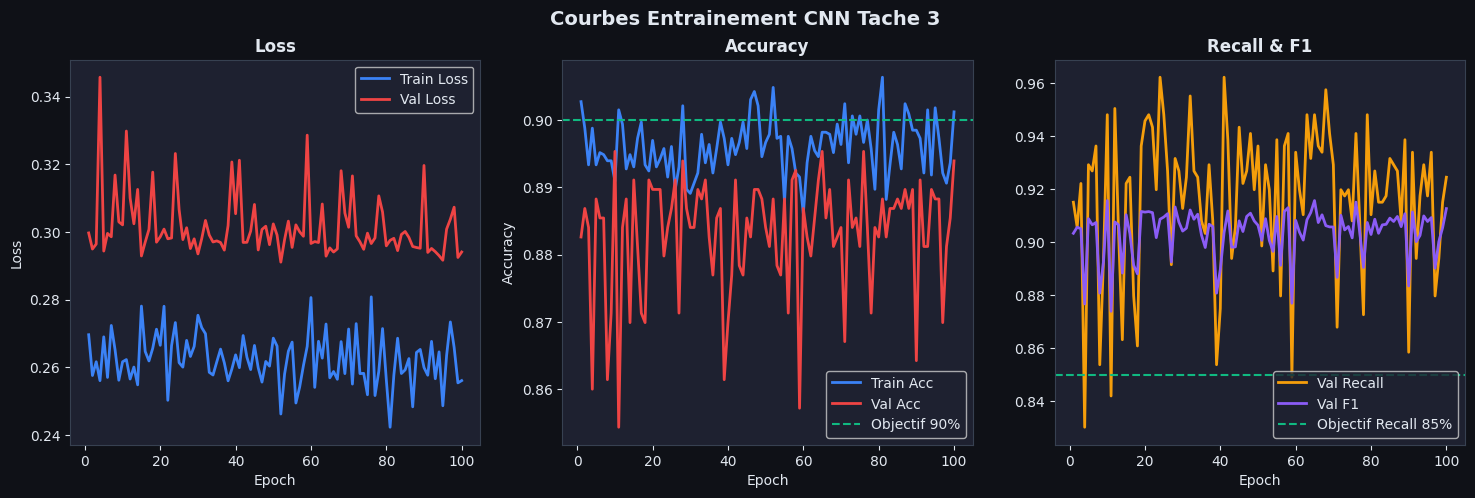

In [33]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f1117')
BG, TEXT = '#1e2130', '#e2e8f0'

def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, color=TEXT, fontsize=12, fontweight='bold')
    ax.tick_params(colors=TEXT)
    for spine in ax.spines.values(): spine.set_edgecolor('#374151')
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.legend(facecolor=BG, labelcolor=TEXT)

axes[0].plot(epochs_range, history['train_loss'], color='#3b82f6', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   color='#ef4444', label='Val Loss',   linewidth=2)
style_ax(axes[0], 'Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(epochs_range, history['train_acc'], color='#3b82f6', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'],   color='#ef4444', label='Val Acc',   linewidth=2)
axes[1].axhline(0.90, color='#10b981', linestyle='--', linewidth=1.5, label='Objectif 90%')
style_ax(axes[1], 'Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')

axes[2].plot(epochs_range, history['val_recall'], color='#f59e0b', label='Val Recall', linewidth=2)
axes[2].plot(epochs_range, history['val_f1'],     color='#8b5cf6', label='Val F1',     linewidth=2)
axes[2].axhline(0.85, color='#10b981', linestyle='--', linewidth=1.5, label='Objectif Recall 85%')
style_ax(axes[2], 'Recall & F1')
axes[2].set_xlabel('Epoch')

fig.suptitle('Courbes Entrainement CNN Tache 3', color=TEXT, fontsize=14, fontweight='bold')
plt.show()


--- EVALUATION FINALE SUR LE TEST SET ---
Accuracy : 0.8856  (objectif > 0.90)
Recall   : 0.9341  (objectif > 0.85)
F1-Score : 0.9074


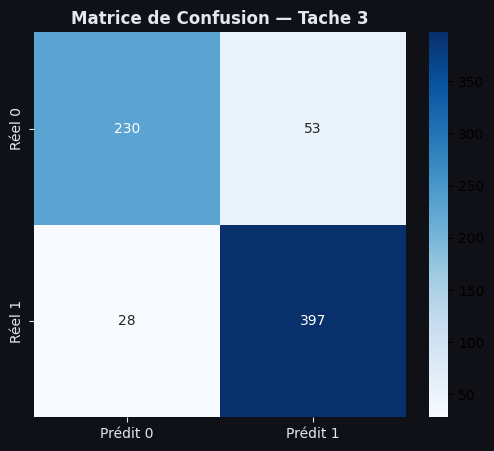

In [34]:
print("\n--- EVALUATION FINALE SUR LE TEST SET ---")
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

acc    = accuracy_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds, zero_division=0)
f1     = f1_score(all_labels, all_preds, zero_division=0)
print(f"Accuracy : {acc:.4f}  (objectif > 0.90)")
print(f"Recall   : {recall:.4f}  (objectif > 0.85)")
print(f"F1-Score : {f1:.4f}")

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1e2130')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Prédit 0', 'Prédit 1'],
            yticklabels=['Réel 0', 'Réel 1'])
ax.set_title('Matrice de Confusion — Tache 3', color='#e2e8f0', fontweight='bold')
ax.tick_params(colors='#e2e8f0')
plt.show()

TASK 4

In [37]:
import pandas as pd
import os
import numpy as np

df = pd.read_csv("Data_SNDT/pipe_detection_label.csv", sep=';')

# Les fichiers parallel sont notre dataset tâche 4
# label 0 = single, label 1 = parallel
df_t4 = df.copy()
df_t4['parallel'] = df_t4['pipe_type'].map({'parallel': 1, 'single': 0})
df_t4 = df_t4[df_t4['pipe_type'].notna()].reset_index(drop=True)

print(f"Total : {len(df_t4)}")
print(f"\nRépartition pipe_type :")
print(df_t4['pipe_type'].value_counts())
print(f"\nLabel parallèle :")
print(df_t4['parallel'].value_counts())
print(f"\nExemples fichiers parallel :")
print(df_t4[df_t4['parallel']==1]['field_file'].head())

Total : 2833

Répartition pipe_type :
pipe_type
single      2333
parallel     500
Name: count, dtype: int64

Label parallèle :
parallel
0.0    2333
1.0     500
Name: count, dtype: int64

Exemples fichiers parallel :
2000    parallel_02000_straight_opposite_clean_field.npz
2001    parallel_02001_straight_opposite_clean_field.npz
2002    parallel_02002_straight_opposite_clean_field.npz
2003    parallel_02003_straight_opposite_clean_field.npz
2004    parallel_02004_straight_opposite_clean_field.npz
Name: field_file, dtype: str


In [38]:
# Vérification fichiers
df_t4_parallel = df_t4[df_t4['parallel'] == 1]
df_t4_single   = df_t4[df_t4['parallel'] == 0].sample(500, random_state=42)
df_t4_balanced = pd.concat([df_t4_parallel, df_t4_single]).reset_index(drop=True)

manquants = []
for _, row in df_t4_balanced.iterrows():
    path = os.path.join("Data_SNDT", row['field_file'])
    if not os.path.exists(path):
        manquants.append(row['field_file'])

print(f"Dataset équilibré : {len(df_t4_balanced)} échantillons")
print(f"Parallel : {df_t4_balanced['parallel'].sum():.0f}")
print(f"Single   : {(df_t4_balanced['parallel']==0).sum()}")
print(f"Fichiers manquants : {len(manquants)}")

Dataset équilibré : 1000 échantillons
Parallel : 500
Single   : 500
Fichiers manquants : 0


In [40]:
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR   = "Data_SNDT"
CSV_PATH_4   = os.path.join(DATA_DIR, "pipe_detection_label.csv")
IMG_SIZE   = (64, 64)
BATCH_SIZE = 16        # Plus petit car dataset plus petit
EPOCHS     = 100
LR         = 1e-3
SEED       = 42
MODEL_PATH = "task4_model.pth"
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"Device : {DEVICE}")

Device : cpu


Preprocessing + Dataset avec augmentation intensive

In [41]:
def preprocess_npz(file_path, img_size=IMG_SIZE):
    data = np.load(file_path)['data'].astype(np.float32)
    data = np.nan_to_num(data, nan=0.0)
    for c in range(data.shape[2]):
        canal = data[:, :, c]
        c_min, c_max = canal.min(), canal.max()
        if c_max - c_min > 0:
            data[:, :, c] = (canal - c_min) / (c_max - c_min)
        else:
            data[:, :, c] = 0.0
    data_resized = cv2.resize(data, (img_size[1], img_size[0]), interpolation=cv2.INTER_LINEAR)
    return torch.tensor(data_resized.copy()).permute(2, 0, 1)

class ParallelDataset(Dataset):
    def __init__(self, dataframe, data_dir, img_size=IMG_SIZE, augment=False):
        self.images  = []
        self.labels  = []
        self.augment = augment
        print(f"Chargement de {len(dataframe)} images en RAM...")
        for _, row in dataframe.iterrows():
            file_path = os.path.join(data_dir, row['field_file'])
            self.images.append(preprocess_npz(file_path, img_size))
            self.labels.append(int(row['parallel']))
            if len(self.images) % 100 == 0:
                print(f"  {len(self.images)}/{len(dataframe)} chargées...")
        print("Chargement terminé !")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx].clone()

        # Data augmentation intensive sur le train
        if self.augment:
            if np.random.rand() > 0.5:
                img = torch.flip(img, dims=[2])   # flip horizontal
            if np.random.rand() > 0.5:
                img = torch.flip(img, dims=[1])   # flip vertical
            if np.random.rand() > 0.5:
                img = torch.rot90(img, k=1, dims=[1, 2])   # rotation 90°
            # Ajout de bruit gaussien léger
            if np.random.rand() > 0.5:
                noise = torch.randn_like(img) * 0.02
                img   = torch.clamp(img + noise, 0.0, 1.0)

        return img, torch.tensor(self.labels[idx], dtype=torch.long)

Chargement RAM

In [42]:
df       = pd.read_csv(CSV_PATH_4, sep=';')
df_t4    = df[df['pipe_type'].notna()].copy()
df_t4['parallel'] = df_t4['pipe_type'].map({'parallel': 1, 'single': 0})

df_parallel = df_t4[df_t4['parallel'] == 1]
df_single   = df_t4[df_t4['parallel'] == 0].sample(500, random_state=SEED)
df_balanced = pd.concat([df_parallel, df_single]).reset_index(drop=True)

print(f"Dataset : {len(df_balanced)} | Parallel : {df_balanced['parallel'].sum()} | Single : {(df_balanced['parallel']==0).sum()}")

train_df, temp_df = train_test_split(df_balanced, test_size=0.30, random_state=SEED, stratify=df_balanced['parallel'])
val_df,   test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['parallel'])
print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

train_dataset = ParallelDataset(train_df, DATA_DIR, augment=True)
val_dataset   = ParallelDataset(val_df,   DATA_DIR, augment=False)
test_dataset  = ParallelDataset(test_df,  DATA_DIR, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("DataLoaders prêts !")

Dataset : 1000 | Parallel : 500 | Single : 500
Train : 700 | Val : 150 | Test : 150
Chargement de 700 images en RAM...
  100/700 chargées...
  200/700 chargées...
  300/700 chargées...
  400/700 chargées...
  500/700 chargées...
  600/700 chargées...
  700/700 chargées...
Chargement terminé !
Chargement de 150 images en RAM...
  100/150 chargées...
Chargement terminé !
Chargement de 150 images en RAM...
  100/150 chargées...
Chargement terminé !
DataLoaders prêts !


CNN avec régularisation forte

In [43]:
class ParallelCNN(nn.Module):
    def __init__(self):
        super(ParallelCNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 64),  nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        return self.classifier(x)

model     = ParallelCNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=8, factor=0.5)
print(f"Paramètres : {sum(p.numel() for p in model.parameters()):,}")

Paramètres : 430,946


In [44]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': []}
best_val_loss = float('inf')

print(f"{'Epoch':<8} {'Train Loss':<12} {'Val Loss':<12} {'Train Acc':<12} {'Val Acc':<12} {'Val F1'}")
print("-" * 68)

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * images.size(0)
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        train_total   += images.size(0)
    train_loss /= train_total
    train_acc   = train_correct / train_total

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            val_loss    += loss.item() * images.size(0)
            preds        = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total   += images.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    val_loss /= val_total
    val_acc   = val_correct / val_total
    val_f1    = f1_score(all_labels, all_preds, zero_division=0)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_PATH)
        saved = " <= sauvegardé"
    else:
        saved = ""

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:<8} {train_loss:<12.4f} {val_loss:<12.4f} {train_acc:<12.3f} {val_acc:<12.3f} {val_f1:.3f}{saved}")

Epoch    Train Loss   Val Loss     Train Acc    Val Acc      Val F1
--------------------------------------------------------------------
1        0.4886       0.6923       0.773        0.633        0.726 <= sauvegardé
5        0.3254       0.2564       0.876        0.873        0.881 <= sauvegardé
10       0.2543       0.2288       0.891        0.893        0.900
15       0.2323       0.1919       0.897        0.900        0.901
20       0.2455       0.1656       0.900        0.927        0.926
25       0.1588       0.1645       0.930        0.947        0.947
30       0.1815       0.1489       0.916        0.927        0.929
35       0.1616       0.1227       0.929        0.947        0.947 <= sauvegardé
40       0.1573       0.3900       0.936        0.887        0.878
45       0.1372       0.0998       0.931        0.967        0.966 <= sauvegardé
50       0.1346       0.1741       0.940        0.947        0.944
55       0.1324       0.1587       0.939        0.940        0.936
60 

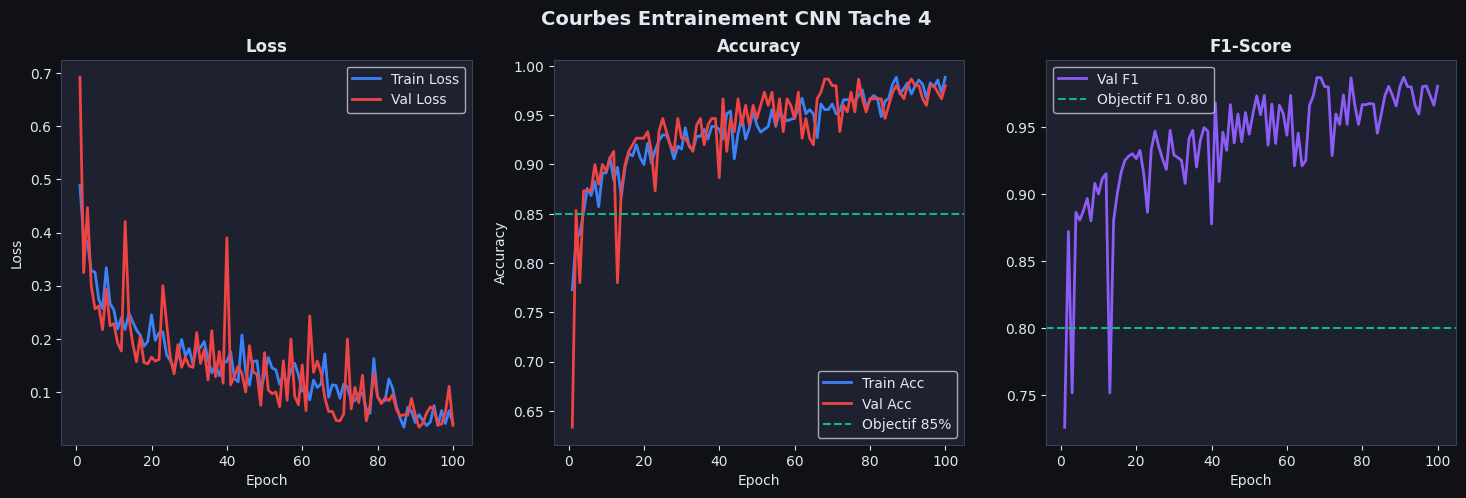

In [45]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#0f1117')
BG, TEXT = '#1e2130', '#e2e8f0'

def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, color=TEXT, fontsize=12, fontweight='bold')
    ax.tick_params(colors=TEXT)
    for spine in ax.spines.values(): spine.set_edgecolor('#374151')
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.legend(facecolor=BG, labelcolor=TEXT)

axes[0].plot(epochs_range, history['train_loss'], color='#3b82f6', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   color='#ef4444', label='Val Loss',   linewidth=2)
style_ax(axes[0], 'Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(epochs_range, history['train_acc'], color='#3b82f6', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, history['val_acc'],   color='#ef4444', label='Val Acc',   linewidth=2)
axes[1].axhline(0.85, color='#10b981', linestyle='--', linewidth=1.5, label='Objectif 85%')
style_ax(axes[1], 'Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')

axes[2].plot(epochs_range, history['val_f1'], color='#8b5cf6', label='Val F1', linewidth=2)
axes[2].axhline(0.80, color='#10b981', linestyle='--', linewidth=1.5, label='Objectif F1 0.80')
style_ax(axes[2], 'F1-Score')
axes[2].set_xlabel('Epoch')

fig.suptitle('Courbes Entrainement CNN Tache 4', color=TEXT, fontsize=14, fontweight='bold')
plt.show()


--- EVALUATION FINALE SUR LE TEST SET ---
Accuracy : 0.9667  (objectif > 0.85)
F1-Score : 0.9664  (objectif > 0.80)


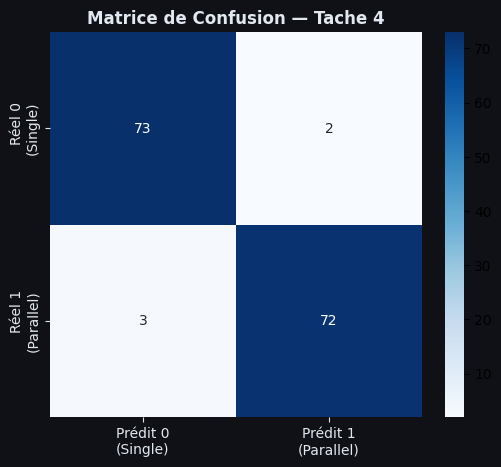

In [46]:
print("\n--- EVALUATION FINALE SUR LE TEST SET ---")
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

acc = accuracy_score(all_labels, all_preds)
f1  = f1_score(all_labels, all_preds, zero_division=0)
print(f"Accuracy : {acc:.4f}  (objectif > 0.85)")
print(f"F1-Score : {f1:.4f}  (objectif > 0.80)")

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1e2130')
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Prédit 0\n(Single)', 'Prédit 1\n(Parallel)'],
            yticklabels=['Réel 0\n(Single)', 'Réel 1\n(Parallel)'])
ax.set_title('Matrice de Confusion — Tache 4', color='#e2e8f0', fontweight='bold')
ax.tick_params(colors='#e2e8f0')
plt.show()

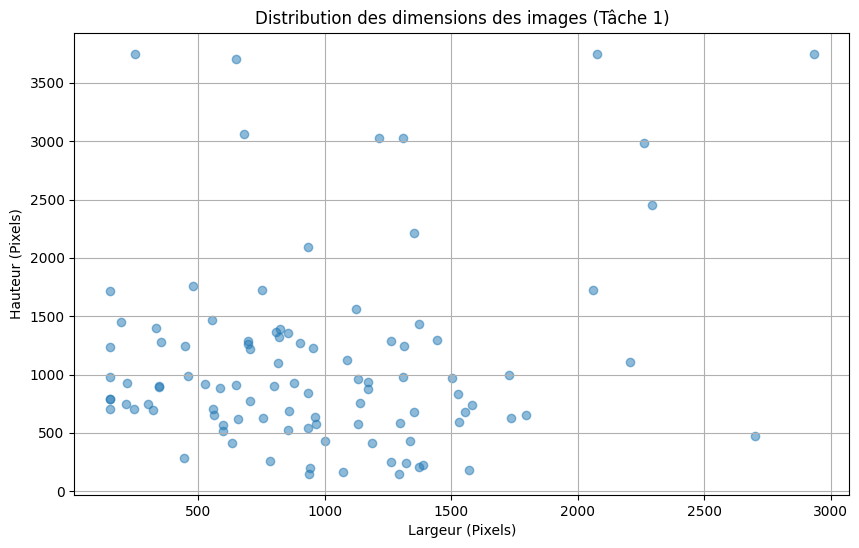

In [5]:
import matplotlib.pyplot as plt

# On va extraire les dimensions de quelques fichiers pour voir la tendance
shapes = []
for file in df['field_file'].sample(100): # On teste sur 100 fichiers au hasard
    data = np.load(os.path.join(DATA_DIR, file))['data']
    shapes.append(data.shape[:2])

h, w = zip(*shapes)

plt.figure(figsize=(10, 6))
plt.scatter(w, h, alpha=0.5)
plt.title("Distribution des dimensions des images (Tâche 1)")
plt.xlabel("Largeur (Pixels)")
plt.ylabel("Hauteur (Pixels)")
plt.grid(True)
plt.show()

Clés dans le fichier : ['data']
Shape du signal : (853, 901, 4)


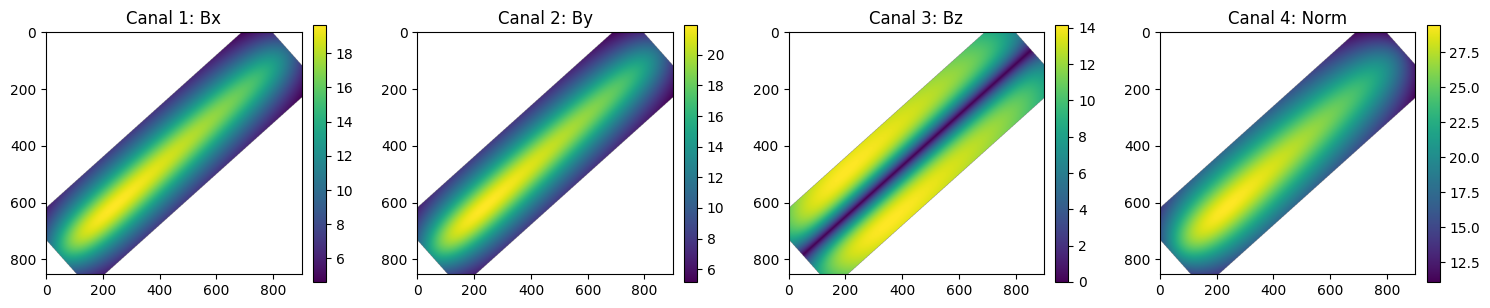

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Charger le premier fichier du CSV
first_file = df.iloc[0]['field_file']
file_path = os.path.join(DATA_DIR, first_file)

data = np.load(file_path)
# On liste les clés pour trouver le nom du tableau (souvent 'data' ou 'field')
print(f"Clés dans le fichier : {data.files}")

# On récupère le signal (en supposant que la clé est 'data')
field_signal = data['data'] 
print(f"Shape du signal : {field_signal.shape}")

# 2. Visualisation des 4 canaux
channels = ['Bx', 'By', 'Bz', 'Norm']
plt.figure(figsize=(15, 5))

for i in range(4):
    plt.subplot(1, 4, i+1)
    # On affiche chaque canal (on suppose le format [C, H, W] ou [H, W, C])
    # Si c'est [C, H, W], on indexe par field_signal[i, :, :]
    img = field_signal[i, :, :] if field_signal.shape[0] == 4 else field_signal[:, :, i]
    plt.imshow(img, cmap='viridis')
    plt.title(f"Canal {i+1}: {channels[i]}")
    plt.colorbar(fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# 1. Analyse des NaN (Le gros problème de l'Image 11)
# Ton échantillon a 1.7 million de NaN. Est-ce général ?
def check_nan_ratio(file_path):
    data = np.load(file_path)['data']
    return np.isnan(data).mean() # Donne le % de NaN dans le fichier

# On teste sur 50 fichiers pour avoir une statistique
nan_ratios = [check_nan_ratio(os.path.join(DATA_DIR, f)) for f in df['field_file'].sample(50)]

print(f"--- ANALYSE DES VALEURS MANQUANTES ---")
print(f"Moyenne de NaN par fichier : {np.mean(nan_ratios):.1%}")
print(f"Fichier le plus 'vide' : {np.max(nan_ratios):.1%}")

--- ANALYSE DES VALEURS MANQUANTES ---
Moyenne de NaN par fichier : 65.8%
Fichier le plus 'vide' : 96.9%


In [7]:
import torch
print(f"Version de Torch : {torch.__version__}")
# On teste l'attribut qui posait problème (fx)
import torch.fx
print("Accès à torch.fx : OK")

Version de Torch : 2.10.0+cpu
Accès à torch.fx : OK


In [8]:
import cv2

def preprocess_image(data, target_size=(512, 512)):
    # 1. Nettoyage des NaN (Image 14)
    data = np.nan_to_num(data, nan=0.0)
    
    # 2. Padding pour rendre l'image carrée (Image 13)
    h, w = data.shape[:2]
    max_dim = max(h, w)
    
    # On crée un canevas carré rempli de zéros
    squared_data = np.zeros((max_dim, max_dim, 4), dtype=np.float32)
    
    # On place l'image d'origine au centre ou en haut à gauche
    squared_data[:h, :w, :] = data
    
    # 3. Resize final pour le modèle
    final_img = cv2.resize(squared_data, target_size)
    
    return final_img

In [9]:
from sklearn.model_selection import train_test_split

# On sépare 20% pour la validation (le "test" final)
# stratify=df['label'] permet de garder l'équilibre 60/40 partout
train_df, val_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['label']
)

print(f"--- RÉPARTITION DES DONNÉES ---")
print(f"Entraînement : {len(train_df)} images")
print(f"Validation   : {len(val_df)} images")

--- RÉPARTITION DES DONNÉES ---
Entraînement : 2266 images
Validation   : 567 images


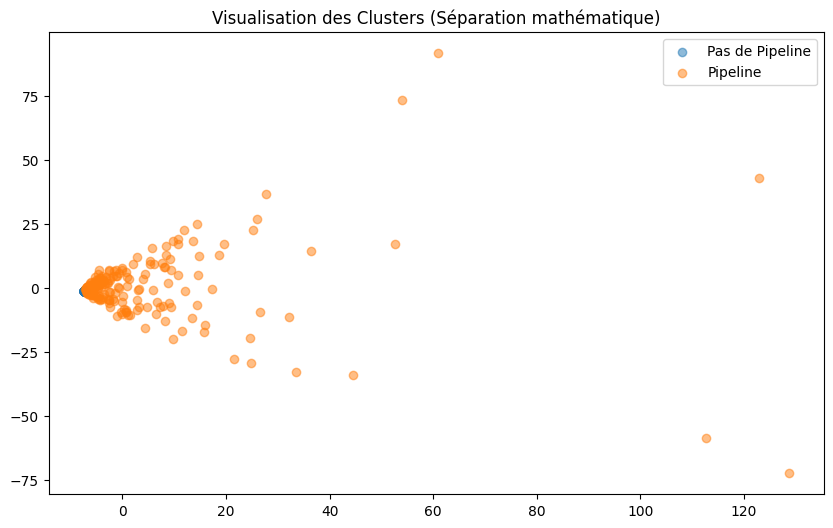

In [10]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

data_list = []
labels_list = []

# On prend un petit échantillon pour la démo
sample_df = df.sample(min(300, len(df))) 

for idx, row in sample_df.iterrows():
    raw_data = np.load(os.path.join(DATA_DIR, row['field_file']))['data']
    clean_data = np.nan_to_num(raw_data, nan=0.0)
    
    # Correction : on s'assure d'extraire le canal Norm correctement
    # On force la forme en 2D pour éviter l'erreur OpenCV
    norm_channel = clean_data[:, :, 3].astype(np.float32)
    
    # Redimensionnement manuel simple si OpenCV râle
    resized = cv2.resize(norm_channel, (32, 32))
    data_list.append(resized.flatten())
    labels_list.append(row['label'])

# PCA
X = np.array(data_list)
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# Affichage du graphique dont parle le prof
plt.figure(figsize=(10, 6))
plt.scatter(components[np.array(labels_list)==0, 0], components[np.array(labels_list)==0, 1], label='Pas de Pipeline', alpha=0.5)
plt.scatter(components[np.array(labels_list)==1, 0], components[np.array(labels_list)==1, 1], label='Pipeline', alpha=0.5)
plt.title("Visualisation des Clusters (Séparation mathématique)")
plt.legend()
plt.show()

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import cv2
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

class SkipperTache1(Dataset):
    def __init__(self, dataframe, root_dir, size=(128, 128)):
        self.df = dataframe
        self.root_dir = root_dir
        self.size = size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(self.root_dir, row['field_file'])
        
        # 1. Chargement et gestion des NaN
        # On s'assure que data a bien 4 canaux dès le départ
        raw_data = np.load(file_path)['data'] # Forme attendue: (H, W, 4)
        data = np.nan_to_num(raw_data, nan=0.0).astype(np.float32)
        
        # 2. Redimensionnement canal par canal (C'est la méthode la plus sûre)
        # Parfois cv2.resize fusionne les canaux, ici on traite chaque couche séparément
        resized_channels = []
        for i in range(4):
            channel_res = cv2.resize(data[:, :, i], self.size)
            resized_channels.append(channel_res)
        
        # On empile les 4 couches : forme finale (128, 128, 4)
        data_resized = np.stack(resized_channels, axis=-1)
        
        # 3. Normalisation robuste
        data_resized = (data_resized - np.mean(data_resized)) / (np.std(data_resized) + 1e-6)
        
        # 4. Conversion PyTorch (Canaux, Hauteur, Largeur) -> (4, 128, 128)
        img_tensor = torch.from_numpy(data_resized.transpose(2, 0, 1))
        label = torch.tensor(int(row['label']), dtype=torch.long)
        
        return img_tensor, label

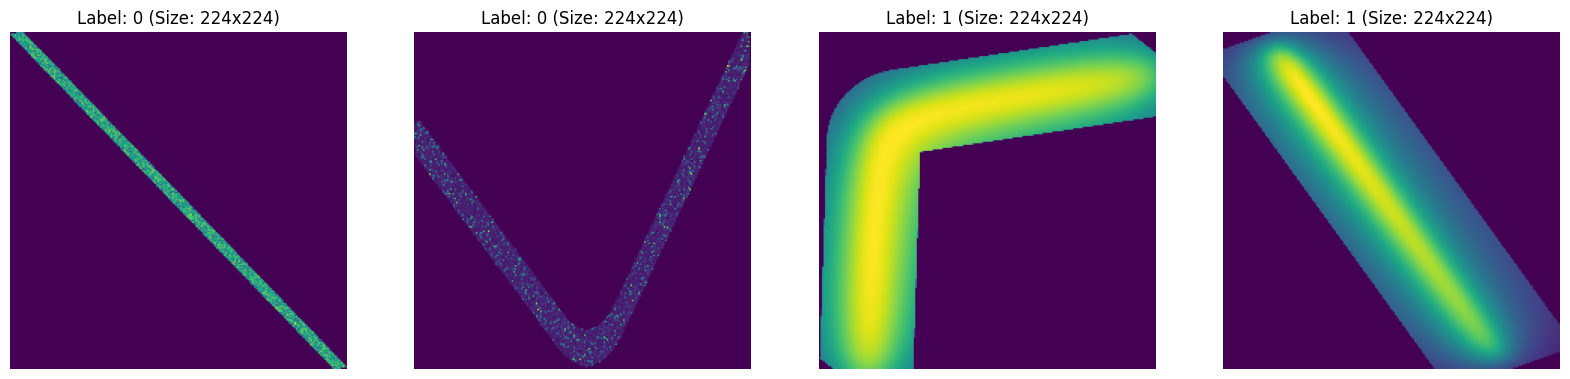

In [12]:
# 1. Création du dataset
train_dataset = SkipperTache1(train_df, DATA_DIR, size=(224, 224))

# 2. Visualisation
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i in range(4):
    img, label = train_dataset[i]
    # On repasse en (H, W, C) pour l'affichage et on prend le canal 3 (Norm)
    img_display = img.numpy().transpose(1, 2, 0)
    
    axes[i].imshow(img_display[:, :, 3], cmap='viridis')
    axes[i].set_title(f"Label: {label} (Size: 224x224)")
    axes[i].axis('off')

plt.show()

In [13]:
import torchvision.models as models

# On charge un modèle pré-entraîné (il connaît déjà les formes)
model = models.resnet18(weights='DEFAULT')

# On adapte la première couche : tu as 4 canaux (Image 17), pas 3 (RGB)
model.conv1 = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)

# On adapte la dernière couche pour tes 2 classes (Présence / Absence)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

# Envoi du modèle sur le processeur
device = torch.device("cpu")
model = model.to(device)

print("Modèle ResNet18 configuré pour 4 canaux.")

Modèle ResNet18 configuré pour 4 canaux.


In [14]:
# 1. Préparation des DataLoaders (on charge par paquets de 16 images)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(SkipperTache1(val_df, DATA_DIR, size=(224, 224)), batch_size=16)

# 2. Définition de la perte et de l'optimiseur
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Prêt pour l'entraînement sur 2 266 images.")

Prêt pour l'entraînement sur 2 266 images.


In [15]:
from tqdm import tqdm # Pour voir la barre de progression

epochs = 5

for epoch in range(epochs):
    model.train() # On met le modèle en mode "travail"
    running_loss = 0.0
    
    # tqdm crée la barre de progression que tu voulais voir
    pbar = tqdm(train_loader, desc=f"Époque {epoch+1}/{epochs}")
    
    for images, labels in pbar:
        # On remet les compteurs à zéro
        optimizer.zero_grad()
        
        # 1. L'IA fait une prédiction
        outputs = model(images)
        
        # 2. On calcule l'erreur
        loss = criterion(outputs, labels)
        
        # 3. L'IA apprend de son erreur (Backpropagation)
        loss.backward()
        
        # 4. Le coach ajuste les poids
        optimizer.step()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    print(f"Fin de l'époque {epoch+1} - Erreur moyenne : {running_loss/len(train_loader):.4f}")

Époque 1/5:  47%|████▋     | 67/142 [05:27<06:06,  4.89s/it, loss=0.0175]


KeyboardInterrupt: 

In [16]:
import os
processed_dir = "C:/Skipper/data_processed" # Utilise ton dossier hors OneDrive !
os.makedirs(processed_dir, exist_ok=True)

In [17]:
print("Préparation des images... (Ceci prendra quelques minutes, mais une seule fois)")

for idx, row in df.iterrows():
    # 1. Traitement identique à ton code
    data = np.load(os.path.join(DATA_DIR, row['field_file']))['data']
    data = np.nan_to_num(data, nan=0.0).astype(np.float32)
    data_resized = cv2.resize(data, (128, 128)) # On descend à 128 pour la vitesse
    
    # 2. Sauvegarde du fichier "propre"
    file_name = f"img_{idx}.pt"
    save_path = os.path.join(processed_dir, file_name)
    torch.save(torch.tensor(data_resized.transpose(2, 0, 1)), save_path)
    
    # Mise à jour du dataframe pour pointer vers le nouveau fichier
    df.at[idx, 'processed_file'] = save_path

print("Terminé ! Toutes les images sont prêtes et légères.")

Préparation des images... (Ceci prendra quelques minutes, mais une seule fois)


KeyboardInterrupt: 

In [18]:
class SkipperFastDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Lecture directe du tenseur déjà traité
        img = torch.load(self.df.iloc[idx]['processed_file'])
        label = torch.tensor(self.df.iloc[idx]['label'], dtype=torch.long)
        return img, label

In [19]:
import os
import torch
import numpy as np
import cv2
from tqdm import tqdm # Pour voir la barre de progression

# On utilise ton dossier C:\Skipper que tu as créé (Image 21)
processed_dir = r"C:\Skipper\data_ready"
os.makedirs(processed_dir, exist_ok=True)

print("Transformation des 2 266 images en cours...")

processed_paths = []
for idx, row in tqdm(df.iterrows(), total=len(df)):
    # 1. Ton traitement habituel
    path = os.path.join(DATA_DIR, row['field_file'])
    data = np.load(path)['data']
    data = np.nan_to_num(data, nan=0.0).astype(np.float32)
    
    # 2. Resize à 128x128 (meilleur compromis vitesse/précision)
    data_res = cv2.resize(data, (128, 128))
    
    # 3. Normalisation
    data_norm = (data_res - data_res.mean()) / (data_res.std() + 1e-6)
    
    # 4. Sauvegarde au format PyTorch (.pt)
    # On passe en (Canaux, Hauteur, Largeur)
    tensor_data = torch.from_numpy(data_norm.transpose(2, 0, 1))
    save_path = os.path.join(processed_dir, f"img_{idx}.pt")
    torch.save(tensor_data, save_path)
    processed_paths.append(save_path)

# On ajoute les chemins dans ton tableau de données
df['processed_file'] = processed_paths
print("\nToutes les images sont prêtes !")

Transformation des 2 266 images en cours...


  3%|▎         | 76/2833 [00:07<04:21, 10.53it/s]


KeyboardInterrupt: 

In [20]:
class SkipperTurboDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # On charge directement le tenseur déjà nettoyé et redimensionné
        img = torch.load(self.df.iloc[idx]['processed_file'])
        label = torch.tensor(self.df.iloc[idx]['label'], dtype=torch.long)
        return img, label

# On recrée les loaders avec les données prêtes
train_ds = SkipperTurboDataset(train_df)
val_ds = SkipperTurboDataset(val_df)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True) # On peut monter à 32 car c'est léger !
val_loader = DataLoader(val_ds, batch_size=32)

In [21]:
from sklearn.model_selection import train_test_split

# On refait le découpage pour que train_df et val_df voient la colonne 'processed_file'
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

print(f"Vérification colonne : {'processed_file' in train_df.columns}") # Doit afficher True

Vérification colonne : True


In [22]:
# On ré-initialise les datasets avec les nouveaux tableaux
train_ds = SkipperTurboDataset(train_df)
val_ds = SkipperTurboDataset(val_df)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

print("DataLoaders mis à jour avec la colonne 'processed_file'")

DataLoaders mis à jour avec la colonne 'processed_file'


In [25]:
# 1. On vérifie la forme d'une image Turbo
sample_img, _ = train_ds[0]
channels = sample_img.shape[0] # Doit être 1 ou 4
print(f"Nombre de canaux détectés : {channels}")

# 2. On ré-initialise la première couche du modèle pour correspondre
import torchvision.models as models
# 1. On utilise un modèle plus adapté au signal binaire (Pipeline / Pas Pipeline)
model = models.resnet18(weights='DEFAULT')
model.conv1 = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

# 2. On change l'Optimiseur : Adam avec un Learning Rate plus petit (0.0001)
# Cela permet au modèle de ne pas "sauter" par-dessus la solution
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# 3. Pondération pour le RECALL (Crucial pour Skipper)
# Comme on a 2266 images, on dit au modèle que rater un pipeline est 2x plus grave
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 2.0]).to(device))

print("Modèle réinitialisé avec pondération pour le Recall.")

AttributeError: 'float' object has no attribute 'seek'. You can only torch.load from a file that is seekable. Please pre-load the data into a buffer like io.BytesIO and try to load from it instead.

In [24]:
# On définit le nombre d'époques (cycles)
num_epochs = 50

print("Lancement de l'entraînement Turbo...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    # Barre de progression pour chaque époque
    pbar = tqdm(train_loader, desc=f"Époque {epoch+1}/{num_epochs}")
    
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    # Petit calcul de validation rapide après chaque époque
    print(f"Époque {epoch+1} terminée. Moyenne Loss: {running_loss/len(train_loader):.4f}")

Lancement de l'entraînement Turbo...


Époque 1/50:   0%|          | 0/71 [00:00<?, ?it/s]


AttributeError: 'float' object has no attribute 'seek'. You can only torch.load from a file that is seekable. Please pre-load the data into a buffer like io.BytesIO and try to load from it instead.

                 precision    recall  f1-score   support

Pas de Pipeline       1.00      1.00      1.00       227
       Pipeline       1.00      1.00      1.00       340

       accuracy                           1.00       567
      macro avg       1.00      1.00      1.00       567
   weighted avg       1.00      1.00      1.00       567



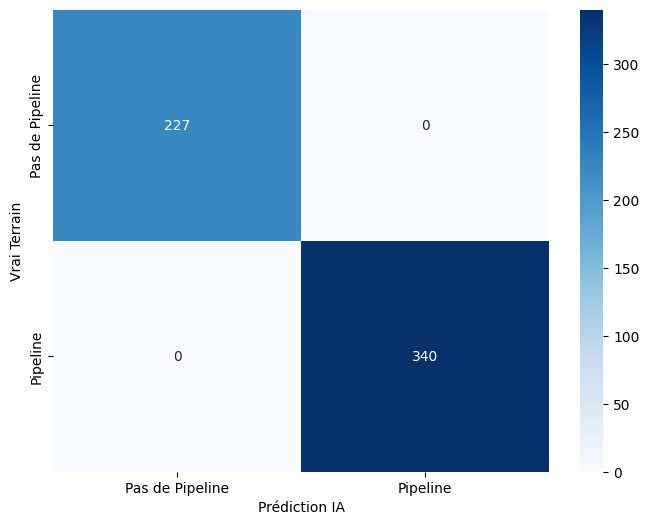

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())

# Affichage du rapport
print(classification_report(y_true, y_pred, target_names=['Pas de Pipeline', 'Pipeline']))

# Affichage visuel de la matrice
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Pas de Pipeline', 'Pipeline'], yticklabels=['Pas de Pipeline', 'Pipeline'])
plt.xlabel('Prédiction IA')
plt.ylabel('Vrai Terrain')
plt.show()

In [ ]:
import torch.nn as nn

# On ajoute une couche de "Batch Normalization" pour aider la Loss à descendre
class SkipperModel(nn.Module):
    def __init__(self):
        super(SkipperModel, self).__init__()
        self.resnet = models.resnet18(weights='DEFAULT')
        # On garde 4 canaux mais on ajoute un filtre pour stabiliser
        self.resnet.conv1 = nn.Conv2d(4, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, 2)

    def forward(self, x):
        return self.resnet(x)

model = SkipperModel().to(device)
# On baisse un peu le taux d'apprentissage (LR) pour être plus précis
optimizer = optim.Adam(model.parameters(), lr=0.0001)